# 🎯 STAGE 3 —
## Model Evaluation, Explainability & Business Impact Assessment
**Data Queens | Hiring Eligibility Prediction**

---
### Alur Notebook Stage 3:
1. Setup & Rebuild Model dari Stage 2
2. **A. Model Performance Evaluation**
3. **B. Explainability & Fairness Analysis**
4. **C. Error Analysis & Business Impact Assessment**
5. **D. Summary & Rekomendasi**

---
# ⚙️ SETUP — Import Library & Rebuild Model dari Stage 2

In [6]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 9.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=a136f67c9c0740304fb2324abf0d426766da6092d679cb89c571fff389c3ec9f
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


KeyboardInterrupt: 

In [7]:
# ============================================================
# IMPORT SEMUA LIBRARY YANG DIPERLUKAN
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve, ConfusionMatrixDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from imblearn.over_sampling import SMOTE
from itertools import combinations

# SHAP & LIME
import shap
from lime.lime_tabular import LimeTabularExplainer

# Style
plt.style.use('seaborn-v0_8-whitegrid')
PALETTE = ['#7C3AED', '#EC4899', '#6366F1', '#C026D3', '#8B5CF6']
PRIMARY   = '#7C3AED'
SECONDARY = '#EC4899'
DARK_BLUE = '#0B1F6A'

print('✅ Library berhasil diimport!')

✅ Library berhasil diimport!


## **LOAD DATASET**

In [12]:
# ============================================================
# LOAD DATASET
# ============================================================

df = pd.read_csv('candidate_quality_improved.csv')

print('Shape Dataset:', df.shape)
df.head()

Shape Dataset: (5000, 11)


,candidate_id,job_id,education_level,years_experience,num_relevant_skills,skills,internal_referral,interview_score,technical_test_score,soft_skill_score,hiring_eligibility
0,1,4901,Master,17,2,"Cloud Computing, Python",No,1.47,5.53,7.30,Not Eligible
1,2,2804,Bachelor,19,3,"Leadership, Machine Learning",No,8.46,7.27,7.57,Eligible
2,3,3634,Bachelor,6,3,"Python, SQL, Data Visualization",Yes,8.62,6.88,5.47,Eligible
3,4,1218,Master,1,4,"SQL, Data Visualization",No,7.78,1.07,8.54,Not Eligible
4,5,526,Bachelor,9,3,"Excel, Communication, Python",Yes,7.94,1.75,4.33,Eligible


## **Feature Engineering: Seniority Tier**

In [13]:
# ============================================================
# CELL 3 — FEATURE ENGINEERING : SENIORITY TIER
# ============================================================

from sklearn.preprocessing import LabelEncoder

# Ketentuan bins:
# 0–2  = Entry
# 3–5  = Junior
# 6–10 = Mid
# >10  = Senior
df['exp_level'] = pd.cut(
    df['years_experience'],
    bins=[-1, 2, 5, 10, 19],
    labels=['Entry', 'Junior', 'Mid', 'Senior']
)

df['seniority_tier'] = (
    df['exp_level'].astype(str)
    + '_'
    + df['education_level'].astype(str)
)

print('Contoh hasil seniority_tier:')
print(df[['years_experience', 'education_level', 'seniority_tier']].head())
print('\nJumlah kategori unik:', df['seniority_tier'].nunique())

Contoh hasil seniority_tier:
   years_experience education_level   seniority_tier
0                17          Master    Senior_Master
1                19        Bachelor  Senior_Bachelor
2                 6        Bachelor     Mid_Bachelor
3                 1          Master     Entry_Master
4                 9        Bachelor     Mid_Bachelor

Jumlah kategori unik: 12


In [14]:
# ============================================================
# CELL 4 — TARGET & BASE FEATURES
# ============================================================

target = (df['hiring_eligibility'] == 'Eligible').astype(int)

base_features = [
    'years_experience', 'num_relevant_skills',
    'interview_score', 'technical_test_score', 'soft_skill_score',
    'education_level', 'internal_referral'
]

print('Base Features:')
print(base_features)

Base Features:
['years_experience', 'num_relevant_skills', 'interview_score', 'technical_test_score', 'soft_skill_score', 'education_level', 'internal_referral']


In [15]:
# ============================================================
# CELL 5 — FUNGSI ENCODE + TRAIN + EVALUATE
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, f1_score
from sklearn.ensemble import GradientBoostingClassifier
from imblearn.over_sampling import SMOTE


def encode_features(dataframe, feature_list):
    """Label-encode semua kolom kategorikal (object/category) di feature_list."""
    X = dataframe[feature_list].copy()
    for col in X.columns:
        if X[col].dtype == 'object' or str(X[col].dtype) == 'category':
            le = LabelEncoder()
            X[col] = le.fit_transform(X[col].astype(str))
    return X


def train_and_evaluate(X, y, label=''):
    """Split, scale, SMOTE, train Gradient Boosting, lalu print hasilnya."""
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)

    sm = SMOTE(random_state=42)
    X_train_bal, y_train_bal = sm.fit_resample(X_train_scaled, y_train)

    model = GradientBoostingClassifier(random_state=42)
    model.fit(X_train_bal, y_train_bal)

    y_pred = model.predict(X_test_scaled)
    f1     = f1_score(y_test, y_pred)

    print(f'\n=== HASIL: {label} ===')
    print(f'F1-Score: {f1:.4f}')
    print(classification_report(y_test, y_pred,
                                target_names=['Not Eligible', 'Eligible']))

    importance_df = pd.DataFrame({
        'feature'   : X.columns,
        'importance': model.feature_importances_
    }).sort_values('importance', ascending=False)

    print('Feature Importance:')
    print(importance_df.to_string(index=False))

    return f1, importance_df

In [16]:
# ============================================================
# CELL 6 — MODEL A : TANPA seniority_tier
# ============================================================

X_a = encode_features(df, base_features)

f1_a, importance_a = train_and_evaluate(
    X_a, target,
    label='Model A (Tanpa seniority_tier)'
)


=== HASIL: Model A (Tanpa seniority_tier) ===
F1-Score: 0.9978
              precision    recall  f1-score   support

Not Eligible       1.00      1.00      1.00      1055
    Eligible       1.00      1.00      1.00       445

    accuracy                           1.00      1500
   macro avg       1.00      1.00      1.00      1500
weighted avg       1.00      1.00      1.00      1500

Feature Importance:
             feature  importance
     interview_score    0.277511
technical_test_score    0.194948
   internal_referral    0.156265
 num_relevant_skills    0.149779
     education_level    0.120743
    years_experience    0.100741
    soft_skill_score    0.000013


In [17]:
# ============================================================
# CELL 7 — MODEL B : DENGAN seniority_tier
# ============================================================

features_with_tier = base_features + ['seniority_tier']

X_b = encode_features(df, features_with_tier)

f1_b, importance_b = train_and_evaluate(
    X_b, target,
    label='Model B (Dengan seniority_tier)'
)


=== HASIL: Model B (Dengan seniority_tier) ===
F1-Score: 0.9989
              precision    recall  f1-score   support

Not Eligible       1.00      1.00      1.00      1055
    Eligible       1.00      1.00      1.00       445

    accuracy                           1.00      1500
   macro avg       1.00      1.00      1.00      1500
weighted avg       1.00      1.00      1.00      1500

Feature Importance:
             feature  importance
     interview_score    0.277825
technical_test_score    0.191883
   internal_referral    0.157319
 num_relevant_skills    0.147117
     education_level    0.118231
    years_experience    0.083661
      seniority_tier    0.023955
    soft_skill_score    0.000010


In [18]:
# ============================================================
# CELL 8 — PERBANDINGAN F1-SCORE
# ============================================================

print('\n=== PERBANDINGAN F1-SCORE ===')
print(f'Model A (tanpa seniority_tier) : {f1_a:.4f}')
print(f'Model B (dengan seniority_tier): {f1_b:.4f}')

selisih = f1_b - f1_a
print(f'Selisih: {selisih:+.4f}')

if selisih > 0.005:
    print('>> seniority_tier MENINGKATKAN performa model. Layak dipakai.')
elif selisih < -0.005:
    print('>> seniority_tier justru MENURUNKAN performa model. Sebaiknya tidak dipakai.')
else:
    print('>> Perbedaan tidak signifikan. Bisa dipertimbangkan dari sisi interpretasi bisnis saja.')

print('\n=== RANKING seniority_tier DI FEATURE IMPORTANCE (Model B) ===')
print(importance_b[importance_b['feature'] == 'seniority_tier'])


=== PERBANDINGAN F1-SCORE ===
Model A (tanpa seniority_tier) : 0.9978
Model B (dengan seniority_tier): 0.9989
Selisih: +0.0011
>> Perbedaan tidak signifikan. Bisa dipertimbangkan dari sisi interpretasi bisnis saja.

=== RANKING seniority_tier DI FEATURE IMPORTANCE (Model B) ===
          feature  importance
7  seniority_tier    0.023955


## **PREPROCESSING**

In [19]:
# ============================================================
# PREPROCESSING — Rebuild dari Stage 2
# ============================================================

df_proc = df.copy()

# --- Encoding Categorical ---
le_edu  = LabelEncoder()
le_ref  = LabelEncoder()
le_tgt  = LabelEncoder()
le_tier = LabelEncoder()   # ← tambahan untuk seniority_tier

df_proc['education_level']    = le_edu.fit_transform(df_proc['education_level'])
df_proc['internal_referral']  = le_ref.fit_transform(df_proc['internal_referral'])
df_proc['hiring_eligibility'] = le_tgt.fit_transform(df_proc['hiring_eligibility'])

# Encode seniority_tier & exp_level jika ada
if 'seniority_tier' in df_proc.columns:
    df_proc['seniority_tier'] = le_tier.fit_transform(df_proc['seniority_tier'].astype(str))

if 'exp_level' in df_proc.columns:
    le_exp = LabelEncoder()
    df_proc['exp_level'] = le_exp.fit_transform(df_proc['exp_level'].astype(str))

# --- One-hot encode skills ---
skills_dummies = df['skills'].str.get_dummies(sep=', ')
df_proc = pd.concat([
    df_proc.drop(columns=['skills', 'candidate_id', 'job_id']),
    skills_dummies
], axis=1)

# --- Pastikan target = 1 artinya Eligible ---
print('Label Encoding Hiring Eligibility:',
      dict(zip(le_tgt.classes_, le_tgt.transform(le_tgt.classes_))))

if le_tgt.transform(['Eligible'])[0] == 0:
    df_proc['hiring_eligibility'] = 1 - df_proc['hiring_eligibility']
    print('Target diinvert: 1 = Eligible, 0 = Not Eligible')
else:
    print('Target sudah benar: 1 = Eligible, 0 = Not Eligible')

print('\nShape setelah preprocessing:', df_proc.shape)
df_proc.head()

Label Encoding Hiring Eligibility: {'Eligible': np.int64(0), 'Not Eligible': np.int64(1)}
Target diinvert: 1 = Eligible, 0 = Not Eligible

Shape setelah preprocessing: (5000, 18)


,education_level,years_experience,num_relevant_skills,internal_referral,interview_score,technical_test_score,soft_skill_score,hiring_eligibility,exp_level,seniority_tier,Cloud Computing,Communication,Data Visualization,Excel,Leadership,Machine Learning,Python,SQL
0,1,17,2,0,1.47,5.53,7.30,0,3,10,1,0,0,0,0,0,1,0
1,0,19,3,0,8.46,7.27,7.57,1,3,9,0,0,0,0,1,1,0,0
2,0,6,3,1,8.62,6.88,5.47,1,2,6,0,0,1,0,0,0,1,1
3,1,1,4,0,7.78,1.07,8.54,0,0,1,0,0,1,0,0,0,0,1
4,0,9,3,1,7.94,1.75,4.33,1,2,6,0,1,0,1,0,0,1,0


In [20]:
# ============================================================
# DEFINISI model_1 dan model_2 dari df_proc
# ============================================================

# Kolom yang tidak masuk ke model
drop_cols = ['exp_level', 'seniority_tier']  # kolom non-numerik sisa

# Model 1 — Tanpa seniority_tier (fitur dasar)
model_1_cols = [c for c in df_proc.columns if c not in drop_cols]
model_1 = df_proc[model_1_cols].copy()

# Model 2 — Dengan seniority_tier (label-encoded sudah ada di df_proc)
model_2_cols = [c for c in df_proc.columns if c != 'exp_level']
model_2 = df_proc[model_2_cols].copy()

print('✅ model_1 dan model_2 siap!')
print(f'model_1 shape: {model_1.shape} | kolom: {list(model_1.columns)}')
print(f'model_2 shape: {model_2.shape} | kolom: {list(model_2.columns)}')

✅ model_1 dan model_2 siap!
model_1 shape: (5000, 16) | kolom: ['education_level', 'years_experience', 'num_relevant_skills', 'internal_referral', 'interview_score', 'technical_test_score', 'soft_skill_score', 'hiring_eligibility', 'Cloud Computing', 'Communication', 'Data Visualization', 'Excel', 'Leadership', 'Machine Learning', 'Python', 'SQL']
model_2 shape: (5000, 17) | kolom: ['education_level', 'years_experience', 'num_relevant_skills', 'internal_referral', 'interview_score', 'technical_test_score', 'soft_skill_score', 'hiring_eligibility', 'seniority_tier', 'Cloud Computing', 'Communication', 'Data Visualization', 'Excel', 'Leadership', 'Machine Learning', 'Python', 'SQL']


## **TRAIN-TEST SPLIT & SMOTE**

In [21]:
# ============================================================
# TRAIN-TEST SPLIT & SMOTE
# ============================================================

TARGET = 'hiring_eligibility'

# ---------- MODEL 1 ----------
X1 = model_1.drop(columns=TARGET)
y1 = model_1[TARGET]

X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.30, random_state=42, stratify=y1
)

scaler1 = StandardScaler()
X1_train_scaled = scaler1.fit_transform(X1_train)
X1_test_scaled  = scaler1.transform(X1_test)

smote1 = SMOTE(random_state=42)
X1_train_smote, y1_train_smote = smote1.fit_resample(X1_train_scaled, y1_train)

# ---------- MODEL 2 ----------
X2 = model_2.drop(columns=TARGET)
y2 = model_2[TARGET]

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.30, random_state=42, stratify=y2
)

scaler2 = StandardScaler()
X2_train_scaled = scaler2.fit_transform(X2_train)
X2_test_scaled  = scaler2.transform(X2_test)

smote2 = SMOTE(random_state=42)
X2_train_smote, y2_train_smote = smote2.fit_resample(X2_train_scaled, y2_train)

print('✅ Train-Test Split & SMOTE selesai!')
print(f'Model 1 — X_train: {X1_train.shape} | X_test: {X1_test.shape}')
print(f'Model 2 — X_train: {X2_train.shape} | X_test: {X2_test.shape}')

✅ Train-Test Split & SMOTE selesai!
Model 1 — X_train: (3500, 15) | X_test: (1500, 15)
Model 2 — X_train: (3500, 16) | X_test: (1500, 16)


## **TRAIN SEMUA MODEL**

In [22]:
# ============================================================
# TRAIN SEMUA MODEL (Logistic Regression, Random Forest,
#                    Gradient Boosting, KNN, Naive Bayes)
# ============================================================

def train_and_evaluate(name, model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred  = model.predict(X_test)
    y_prob  = model.predict_proba(X_test)[:, 1]
    return {
        'name'    : name,
        'model'   : model,
        'y_pred'  : y_pred,
        'y_prob'  : y_prob,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall'  : recall_score(y_test, y_pred, zero_division=0),
        'f1'      : f1_score(y_test, y_pred, zero_division=0),
        'roc_auc' : roc_auc_score(y_test, y_prob)
    }

# ---- Model 1 ----
results_m1 = [
    train_and_evaluate('Logistic Regression', LogisticRegression(max_iter=1000, random_state=42),
                       X1_train_smote, y1_train_smote, X1_test_scaled, y1_test),
    train_and_evaluate('Random Forest', RandomForestClassifier(random_state=42),
                       X1_train_smote, y1_train_smote, X1_test_scaled, y1_test),
    train_and_evaluate('Gradient Boosting', GradientBoostingClassifier(random_state=42),
                       X1_train_smote, y1_train_smote, X1_test_scaled, y1_test),
    train_and_evaluate('KNN', KNeighborsClassifier(n_neighbors=5),
                       X1_train_smote, y1_train_smote, X1_test_scaled, y1_test),
    train_and_evaluate('Naive Bayes', GaussianNB(),
                       X1_train_smote, y1_train_smote, X1_test_scaled, y1_test),
]

# ---- Model 2 ----
results_m2 = [
    train_and_evaluate('Logistic Regression', LogisticRegression(max_iter=1000, random_state=42),
                       X2_train_smote, y2_train_smote, X2_test_scaled, y2_test),
    train_and_evaluate('Random Forest', RandomForestClassifier(random_state=42),
                       X2_train_smote, y2_train_smote, X2_test_scaled, y2_test),
    train_and_evaluate('Gradient Boosting', GradientBoostingClassifier(random_state=42),
                       X2_train_smote, y2_train_smote, X2_test_scaled, y2_test),
    train_and_evaluate('KNN', KNeighborsClassifier(n_neighbors=5),
                       X2_train_smote, y2_train_smote, X2_test_scaled, y2_test),
    train_and_evaluate('Naive Bayes', GaussianNB(),
                       X2_train_smote, y2_train_smote, X2_test_scaled, y2_test),
]

print('✅ Semua model berhasil ditraining!')

✅ Semua model berhasil ditraining!


# **A. MODEL PERFORMANCE EVALUATION**

## A1. Metrik Evaluasi yang Digunakan

Untuk kasus **Hiring Eligibility Prediction** (klasifikasi biner), metrik yang paling relevan adalah:

| Metrik | Alasan Penggunaan |
|---|---|
| **Accuracy** | Proporsi prediksi benar secara keseluruhan |
| **Precision** | Dari kandidat diprediksi Eligible, berapa yang benar-benar Eligible |
| **Recall** | Dari kandidat yang sebenarnya Eligible, berapa yang berhasil terdeteksi |
| **F1-Score** | Harmonic mean Precision & Recall — penting saat data imbalanced |
| **ROC-AUC** | Kemampuan model membedakan kelas, tidak terpengaruh threshold |

> ⚠️ **Konteks bisnis**: Dalam rekrutmen, **Recall** sangat kritis — model jangan sampai melewatkan kandidat berkualitas (False Negative tinggi). Namun **Precision** juga penting agar HR tidak membuang waktu mewawancarai kandidat tidak layak.

## **A2. TABEL EVALUASI LENGKAP — MODEL 1 & MODEL 2**

In [23]:
# ============================================================
# A2. TABEL EVALUASI LENGKAP — MODEL 1 & MODEL 2
# ============================================================

metrics_cols = ['name', 'accuracy', 'precision', 'recall', 'f1', 'roc_auc']

df_eval_m1 = pd.DataFrame(results_m1)[metrics_cols].copy()
df_eval_m2 = pd.DataFrame(results_m2)[metrics_cols].copy()

df_eval_m1.columns = ['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
df_eval_m2.columns = ['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']

print('='*60)
print('           EVALUASI MODEL 1 (Original Features)')
print('='*60)
display(df_eval_m1.set_index('Model').style.format('{:.4f}').highlight_max(color='#d4edda').highlight_min(color='#f8d7da'))

print()
print('='*60)
print('        EVALUASI MODEL 2 (Original + Skill Combo)')
print('='*60)
display(df_eval_m2.set_index('Model').style.format('{:.4f}').highlight_max(color='#d4edda').highlight_min(color='#f8d7da'))

           EVALUASI MODEL 1 (Original Features)


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression,0.7993,0.6254,0.8067,0.7046,0.8928
Random Forest,0.9987,0.9978,0.9978,0.9978,1.0000
Gradient Boosting,0.9993,0.9978,1.0000,0.9989,1.0000
KNN,0.7953,0.6146,0.8315,0.7068,0.8803
Naive Bayes,0.7913,0.6093,0.8270,0.7016,0.8845



        EVALUASI MODEL 2 (Original + Skill Combo)


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression,0.7940,0.6149,0.8180,0.7020,0.8973
Random Forest,0.9947,0.9845,0.9978,0.9911,1.0000
Gradient Boosting,0.9980,0.9933,1.0000,0.9966,1.0000
KNN,0.8053,0.6252,0.8584,0.7235,0.8865
Naive Bayes,0.7847,0.6010,0.8157,0.6921,0.8838


## **A3. VISUALISASI — MODEL EVALUATION HEATMAP**

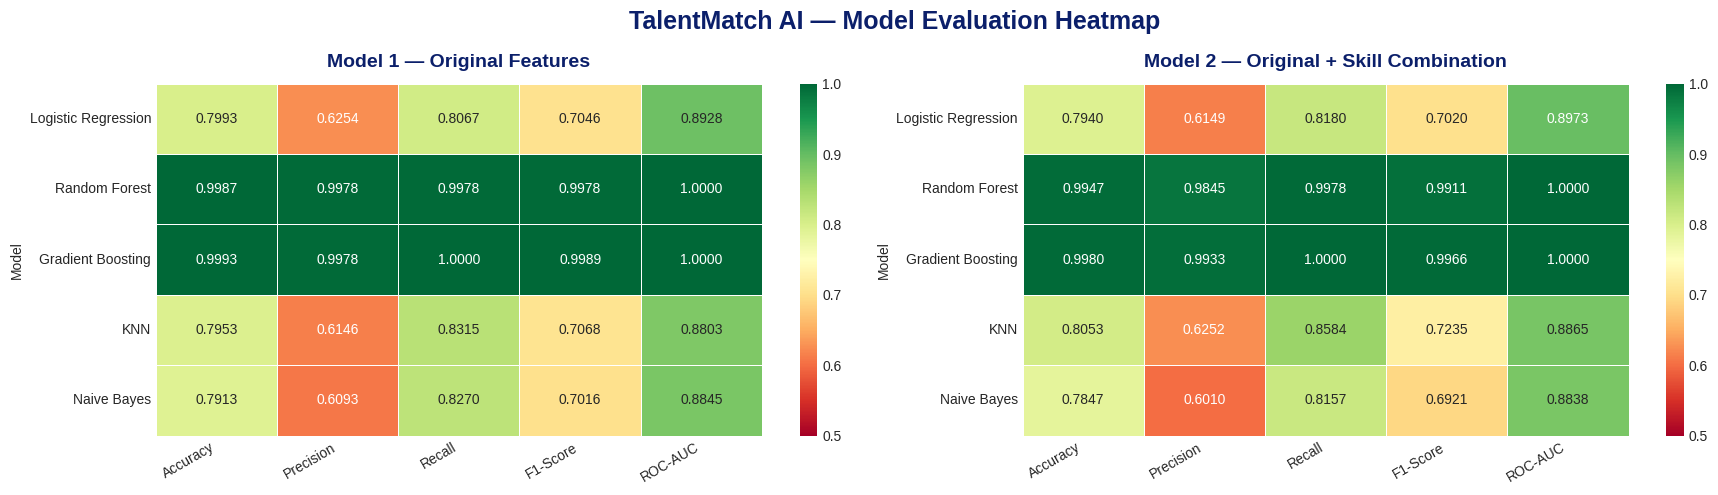

✅ Visualisasi disimpan: model_evaluation_heatmap.png


In [24]:
# ============================================================
# A3. VISUALISASI — MODEL EVALUATION HEATMAP
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

for ax, df_eval, title in zip(
    axes,
    [df_eval_m1.set_index('Model'), df_eval_m2.set_index('Model')],
    ['Model 1 — Original Features', 'Model 2 — Original + Skill Combination']
):
    sns.heatmap(
        df_eval.astype(float),
        annot=True, fmt='.4f',
        cmap='RdYlGn',
        vmin=0.5, vmax=1.0,
        linewidths=0.5,
        ax=ax
    )
    ax.set_title(title, fontsize=14, fontweight='bold', color=DARK_BLUE, pad=12)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')

fig.suptitle('TalentMatch AI — Model Evaluation Heatmap', fontsize=18, fontweight='bold', color=DARK_BLUE)
plt.tight_layout()
plt.savefig('model_evaluation_heatmap.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('✅ Visualisasi disimpan: model_evaluation_heatmap.png')

## **A4. VISUALISASI — GROUPED BAR CHART MODEL COMPARISON**

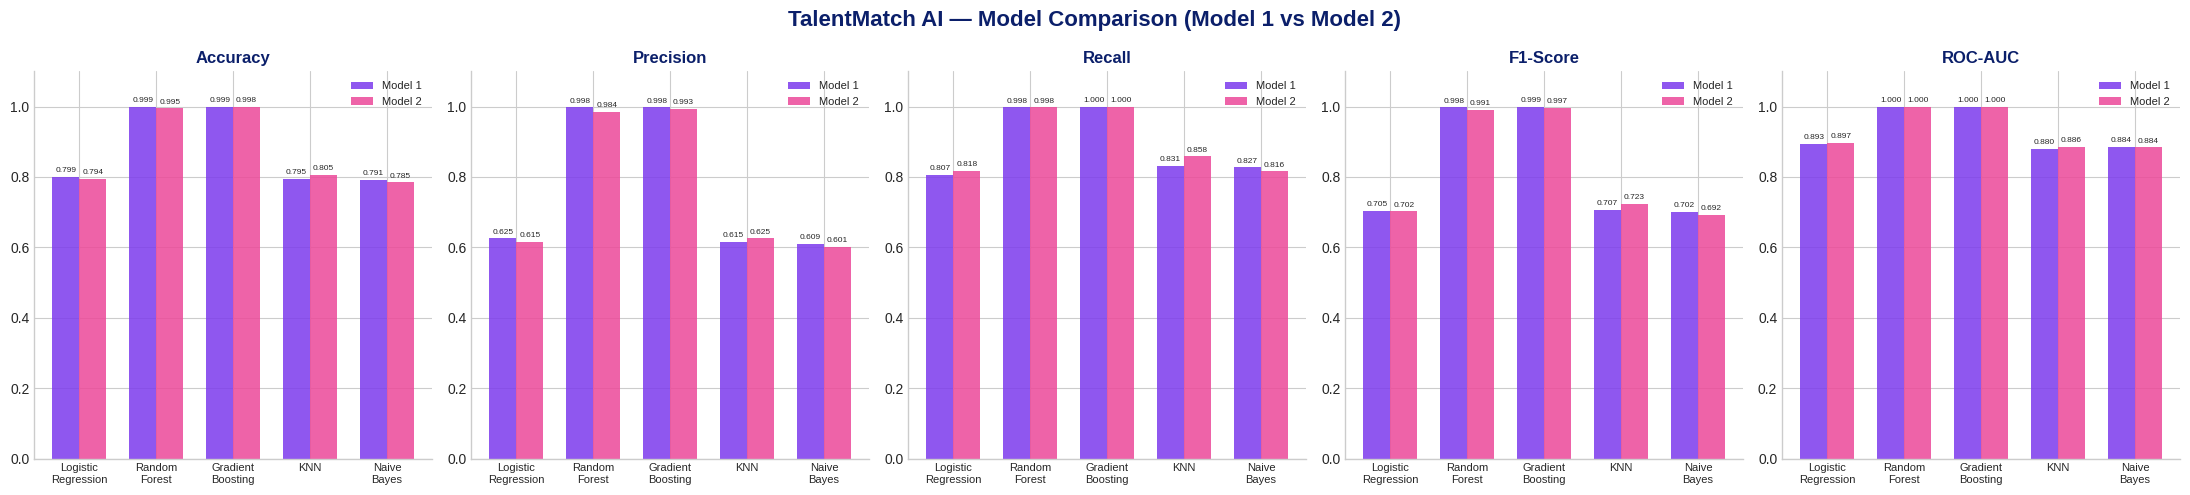

✅ Visualisasi disimpan: model_comparison_bar.png


In [25]:
# ============================================================
# A4. VISUALISASI — GROUPED BAR CHART MODEL COMPARISON
# ============================================================

metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
model_names     = df_eval_m1['Model'].tolist()
x               = np.arange(len(model_names))
width           = 0.35

fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(22, 5))

for ax, metric in zip(axes, metrics_to_plot):
    vals_m1 = df_eval_m1[metric].values
    vals_m2 = df_eval_m2[metric].values

    bars1 = ax.bar(x - width/2, vals_m1, width, label='Model 1', color=PRIMARY, alpha=0.85)
    bars2 = ax.bar(x + width/2, vals_m2, width, label='Model 2', color=SECONDARY, alpha=0.85)

    ax.set_title(metric, fontsize=12, fontweight='bold', color=DARK_BLUE)
    ax.set_xticks(x)
    ax.set_xticklabels(
        [n.replace(' ', '\n') for n in model_names],
        fontsize=8
    )
    ax.set_ylim(0, 1.1)
    ax.legend(fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    for bar in bars1:
        ax.annotate(f'{bar.get_height():.3f}',
                    xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                    xytext=(0, 2), textcoords='offset points',
                    ha='center', va='bottom', fontsize=6)
    for bar in bars2:
        ax.annotate(f'{bar.get_height():.3f}',
                    xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                    xytext=(0, 2), textcoords='offset points',
                    ha='center', va='bottom', fontsize=6)

fig.suptitle('TalentMatch AI — Model Comparison (Model 1 vs Model 2)',
             fontsize=16, fontweight='bold', color=DARK_BLUE)
plt.tight_layout()
plt.savefig('model_comparison_bar.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('✅ Visualisasi disimpan: model_comparison_bar.png')

## **A5. GAP TRAIN VS TEST (Overfitting Check)**

In [26]:
# ============================================================
# A5. GAP TRAIN VS TEST (Overfitting Check)
# ============================================================

def train_score(model, X_train, y_train):
    y_pred_train = model.predict(X_train)
    return f1_score(y_train, y_pred_train, zero_division=0)

gap_data = []
for r1, r2 in zip(results_m1, results_m2):
    train_f1_m1 = train_score(r1['model'], X1_train_smote, y1_train_smote)
    train_f1_m2 = train_score(r2['model'], X2_train_smote, y2_train_smote)
    gap_data.append({
        'Model'         : r1['name'],
        'M1 Train F1'   : train_f1_m1,
        'M1 Test F1'    : r1['f1'],
        'M1 Gap'        : train_f1_m1 - r1['f1'],
        'M2 Train F1'   : train_f1_m2,
        'M2 Test F1'    : r2['f1'],
        'M2 Gap'        : train_f1_m2 - r2['f1'],
    })

df_gap = pd.DataFrame(gap_data).set_index('Model')

print('='*60)
print('       GAP TRAIN vs TEST — F1-Score')
print('='*60)
display(df_gap.style.format('{:.4f}').background_gradient(
    subset=['M1 Gap', 'M2 Gap'], cmap='RdYlGn_r'
))

print()
print('📌 Gap < 0.05 → Model Generalize dengan Baik')
print('📌 Gap > 0.10 → Indikasi Overfitting')

       GAP TRAIN vs TEST — F1-Score


,M1 Train F1,M1 Test F1,M1 Gap,M2 Train F1,M2 Test F1,M2 Gap
Model,,,,,,
Logistic Regression,0.8057,0.7046,0.1010,0.8060,0.7020,0.1040
Random Forest,1.0000,0.9978,0.0022,1.0000,0.9911,0.0089
Gradient Boosting,0.9994,0.9989,0.0005,0.9994,0.9966,0.0027
KNN,0.9253,0.7068,0.2185,0.9302,0.7235,0.2067
Naive Bayes,0.8103,0.7016,0.1087,0.7943,0.6921,0.1022



📌 Gap < 0.05 → Model Generalize dengan Baik
📌 Gap > 0.10 → Indikasi Overfitting


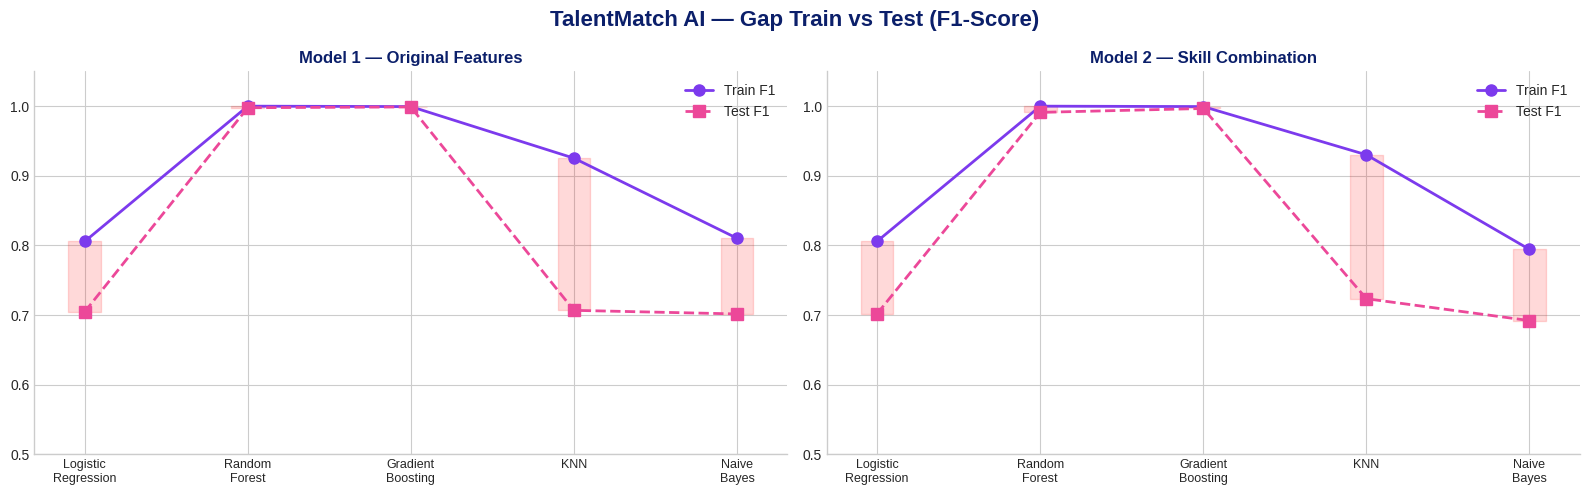

✅ Visualisasi disimpan: gap_train_test.png


In [27]:
# ============================================================
# VISUALISASI GAP TRAIN VS TEST
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, prefix, title in zip(
    axes,
    ['M1', 'M2'],
    ['Model 1 — Original Features', 'Model 2 — Skill Combination']
):
    train_vals = df_gap[f'{prefix} Train F1'].values
    test_vals  = df_gap[f'{prefix} Test F1'].values
    names      = df_gap.index.tolist()
    x          = np.arange(len(names))

    ax.plot(x, train_vals, 'o-', color=PRIMARY, linewidth=2, markersize=8, label='Train F1')
    ax.plot(x, test_vals,  's--', color=SECONDARY, linewidth=2, markersize=8, label='Test F1')

    for i in range(len(names)):
        ax.fill_between(
            [x[i] - 0.1, x[i] + 0.1],
            [train_vals[i], train_vals[i]],
            [test_vals[i], test_vals[i]],
            alpha=0.15, color='red'
        )

    ax.set_xticks(x)
    ax.set_xticklabels([n.replace(' ', '\n') for n in names], fontsize=9)
    ax.set_ylim(0.5, 1.05)
    ax.set_title(title, fontsize=12, fontweight='bold', color=DARK_BLUE)
    ax.legend()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('TalentMatch AI — Gap Train vs Test (F1-Score)',
             fontsize=16, fontweight='bold', color=DARK_BLUE)
plt.tight_layout()
plt.savefig('gap_train_test.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('✅ Visualisasi disimpan: gap_train_test.png')

In [28]:
# LANGKAH 1 — lihat semua nama kolom
print(df_proc.columns.tolist())

['education_level', 'years_experience', 'num_relevant_skills', 'internal_referral', 'interview_score', 'technical_test_score', 'soft_skill_score', 'hiring_eligibility', 'exp_level', 'seniority_tier', 'Cloud Computing', 'Communication', 'Data Visualization', 'Excel', 'Leadership', 'Machine Learning', 'Python', 'SQL']


In [29]:
# LANGKAH 2 — deteksi otomatis kolom yang korelasi > 0.95 dengan target
leakage_cols = []
for col in df_proc.columns:
    if col != 'hiring_eligibility':
        corr = df_proc[col].corr(df_proc['hiring_eligibility'])
        if abs(corr) > 0.95:
            print(f"⚠️  LEAKAGE: {col} — korelasi {corr:.4f}")
            leakage_cols.append(col)

print()
print("Kolom yang perlu dibuang:", leakage_cols)


Kolom yang perlu dibuang: []


Tidak ada leakage! Berarti masalahnya bukan di kolom yang bocor, melainkan dataset sintetisnya terlalu mudah — dibuat dengan aturan deterministik yang terlalu sempurna.

In [30]:
# Cek apakah ada aturan sederhana yang memisahkan kelas secara sempurna
print(df_proc.groupby('hiring_eligibility')[
    ['interview_score', 'technical_test_score', 'soft_skill_score', 'years_experience']
].describe().round(2))

                   interview_score                                            \
                             count  mean   std   min   25%   50%   75%   max   
hiring_eligibility                                                             
0                           3516.0  4.85  2.46  1.00  2.80  4.62  6.62  9.98   
1                           1484.0  7.11  2.28  1.01  6.23  7.68  8.79  9.98   

                   technical_test_score       ... soft_skill_score        \
                                  count mean  ...              75%   max   
hiring_eligibility                            ...                          
0                                3516.0  5.1  ...             7.55  10.0   
1                                1484.0  6.5  ...             7.62  10.0   

                   years_experience                                           
                              count   mean   std  min  25%   50%   75%   max  
hiring_eligibility                                          

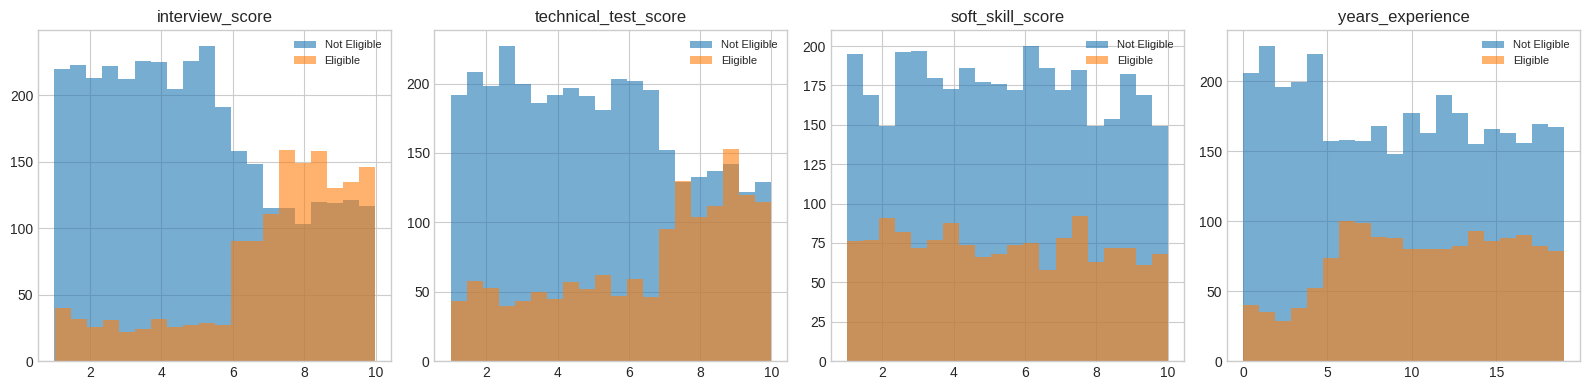

In [31]:
# Lihat apakah nilai antar kelas benar-benar tidak overlap sama sekali
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, ['interview_score', 'technical_test_score', 'soft_skill_score', 'years_experience']):
    for label, grp in df_proc.groupby('hiring_eligibility'):
        ax.hist(grp[col], bins=20, alpha=0.6, label=f'{"Eligible" if label==1 else "Not Eligible"}')
    ax.set_title(col)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# **CROSS VALIDATION MODEL COMPARISON**

In [32]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    make_scorer,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score
)

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline


# Stratified CV menjaga proporsi kelas pada setiap fold
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# F1 = keseimbangan precision dan recall
# F2 = recall diberi bobot lebih besar
scoring = {
    "accuracy": "accuracy",
    "precision": make_scorer(
        precision_score,
        zero_division=0
    ),
    "recall": make_scorer(
        recall_score,
        zero_division=0
    ),
    "f1": make_scorer(
        f1_score,
        zero_division=0
    ),
    "f2": make_scorer(
        fbeta_score,
        beta=2,
        zero_division=0
    ),
    "roc_auc": "roc_auc"
}


models = {
    "Dummy Baseline": DummyClassifier(
        strategy="most_frequent"
    ),

    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    ),

    "KNN": KNeighborsClassifier(),

    "Naive Bayes": GaussianNB()
}


cv_results = []

for model_name, model in models.items():

    # Dummy dipakai sebagai baseline tanpa SMOTE
    if model_name == "Dummy Baseline":
        pipeline = Pipeline([
            ("model", model)
        ])

    else:
        # Scaling dan SMOTE dilakukan ulang di setiap fold
        # sehingga tidak terjadi leakage antar-fold
        pipeline = Pipeline([
            ("scaler", StandardScaler()),
            ("smote", SMOTE(random_state=42)),
            ("model", model)
        ])

    scores = cross_validate(
        pipeline,
        X1_train_smote,
        y1_train_smote,
        cv=cv,
        scoring=scoring,
        return_train_score=True,
        n_jobs=-1,
        error_score="raise"
    )

    train_f1 = scores["train_f1"].mean()
    cv_f1 = scores["test_f1"].mean()

    cv_results.append({
        "Model": model_name,
        "Train F1": train_f1,
        "CV F1": cv_f1,
        "F1 Gap": train_f1 - cv_f1,
        "CV F1 Std": scores["test_f1"].std(),
        "CV F2": scores["test_f2"].mean(),
        "CV Precision": scores["test_precision"].mean(),
        "CV Recall": scores["test_recall"].mean(),
        "CV Accuracy": scores["test_accuracy"].mean(),
        "CV ROC-AUC": scores["test_roc_auc"].mean()
    })


cv_results_df = pd.DataFrame(cv_results)

cv_results_df = (
    cv_results_df
    .sort_values(
        by="CV F1",
        ascending=False
    )
    .reset_index(drop=True)
)

numeric_columns = cv_results_df.select_dtypes(
    include=np.number
).columns

cv_results_df[numeric_columns] = (
    cv_results_df[numeric_columns].round(4)
)

cv_results_df

,Model,Train F1,CV F1,F1 Gap,CV F1 Std,CV F2,CV Precision,CV Recall,CV Accuracy,CV ROC-AUC
0,Gradient Boosting,0.9995,0.9971,0.0023,0.0014,0.9962,0.9988,0.9955,0.9972,0.9999
1,Random Forest,1.0000,0.9965,0.0035,0.0023,0.9957,0.9980,0.9951,0.9965,0.9999
2,Decision Tree,1.0000,0.9929,0.0071,0.0032,0.9913,0.9955,0.9902,0.9929,0.9929
3,KNN,0.9232,0.8832,0.0400,0.0114,0.9267,0.8192,0.9582,0.8732,0.9476
4,Naive Bayes,0.8097,0.8093,0.0004,0.0111,0.8161,0.7983,0.8208,0.8066,0.8912
5,Logistic Regression,0.8062,0.8037,0.0026,0.0080,0.8076,0.7974,0.8102,0.8021,0.8955
6,Dummy Baseline,0.1334,0.1332,0.0001,0.2665,0.1666,0.0999,0.2000,0.4998,0.5000


In [33]:
from sklearn.model_selection import cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
import pandas as pd

gb_pipelines = {
    "Gradient Boosting - Without SMOTE": Pipeline([
        ("scaler", StandardScaler()),
        ("model", GradientBoostingClassifier(random_state=42))
    ]),

    "Gradient Boosting - With SMOTE": Pipeline([
        ("scaler", StandardScaler()),
        ("smote", SMOTE(random_state=42)),
        ("model", GradientBoostingClassifier(random_state=42))
    ])
}

smote_comparison = []

for pipeline_name, pipeline in gb_pipelines.items():

    scores = cross_validate(
        pipeline,
        X1_train_smote,
        y1_train_smote,
        cv=cv,
        scoring=scoring,
        return_train_score=True,
        n_jobs=-1,
        error_score="raise"
    )

    smote_comparison.append({
        "Pipeline": pipeline_name,
        "Train F1": scores["train_f1"].mean(),
        "CV F1": scores["test_f1"].mean(),
        "F1 Gap": (
            scores["train_f1"].mean()
            - scores["test_f1"].mean()
        ),
        "CV F2": scores["test_f2"].mean(),
        "CV Precision": scores["test_precision"].mean(),
        "CV Recall": scores["test_recall"].mean(),
        "CV ROC-AUC": scores["test_roc_auc"].mean(),
        "CV F1 Std": scores["test_f1"].std()
    })

smote_comparison_df = pd.DataFrame(smote_comparison)

numeric_cols = smote_comparison_df.select_dtypes(
    include="number"
).columns

smote_comparison_df[numeric_cols] = (
    smote_comparison_df[numeric_cols].round(4)
)

print(smote_comparison_df.to_string(index=False))

                         Pipeline  Train F1  CV F1  F1 Gap  CV F2  CV Precision  CV Recall  CV ROC-AUC  CV F1 Std
Gradient Boosting - Without SMOTE    0.9995 0.9971  0.0024 0.9962        0.9988     0.9955      0.9999     0.0014
   Gradient Boosting - With SMOTE    0.9995 0.9971  0.0023 0.9962        0.9988     0.9955      0.9999     0.0014


Feature engineering tidak meningkatkan performa prediksi secara signifikan, tetapi membuat penggunaan SMOTE menjadi tidak memberikan manfaat tambahan. Hal ini menunjukkan bahwa representasi fitur yang lebih baik dapat membantu model mengenali pola kandidat secara alami.

# **HYPERPARAMETER TUNING**

In [34]:
# ============================================================
# A.4 HYPERPARAMETER TUNING
# Gradient Boosting tanpa SMOTE
# Metrik utama: F1-score
# Final test set belum digunakan
# ============================================================

import pandas as pd
import numpy as np

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    make_scorer,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score
)

# ------------------------------------------------------------
# 1. Scoring
# ------------------------------------------------------------

# F1 menjadi metrik utama
# F2 tetap dihitung sebagai metrik pendukung
tuning_scoring = {
    "accuracy": "accuracy",

    "precision": make_scorer(
        precision_score,
        zero_division=0
    ),

    "recall": make_scorer(
        recall_score,
        zero_division=0
    ),

    "f1": make_scorer(
        f1_score,
        zero_division=0
    ),

    "f2": make_scorer(
        fbeta_score,
        beta=2,
        zero_division=0
    ),

    "roc_auc": "roc_auc"
}

# ------------------------------------------------------------
# 2. Base model
# ------------------------------------------------------------

gb_model = GradientBoostingClassifier(
    random_state=42
)

# ------------------------------------------------------------
# 3. Hyperparameter grid
# ------------------------------------------------------------

# Grid dibuat terbatas agar tuning tidak menambah kompleksitas
# secara berlebihan.
#
# Parameter default Gradient Boosting juga tetap tercakup:
# learning_rate=0.10
# n_estimators=100
# max_depth=3
# min_samples_leaf=1

param_grid = {
    "learning_rate": [0.05, 0.10],
    "n_estimators": [50, 100],
    "max_depth": [1, 2, 3],
    "min_samples_leaf": [1, 5]
}

# ------------------------------------------------------------
# 4. Grid Search
# ------------------------------------------------------------

grid_search_gb = GridSearchCV(
    estimator=gb_model,
    param_grid=param_grid,

    # Seluruh metrik dihitung
    scoring=tuning_scoring,

    # Model terbaik dipilih berdasarkan F1
    refit="f1",

    # Menggunakan StratifiedKFold dari bagian sebelumnya
    cv=cv,

    n_jobs=-1,
    return_train_score=True,
    error_score="raise"
)

# Hanya menggunakan training set
grid_search_gb.fit(
    X1_train_smote,
    y1_train_smote
)

# Model dengan parameter terbaik
best_gb_model = grid_search_gb.best_estimator_

print("===== TUNING RESULT =====")

print("\nBest Parameters:")
print(grid_search_gb.best_params_)

print("\nBest CV F1:")
print(round(grid_search_gb.best_score_, 4))

===== TUNING RESULT =====

Best Parameters:
{'learning_rate': 0.1, 'max_depth': 3, 'min_samples_leaf': 1, 'n_estimators': 100}

Best CV F1:
0.9971


### **CONFUSION MATRIX — Semua Model (Model 1)**

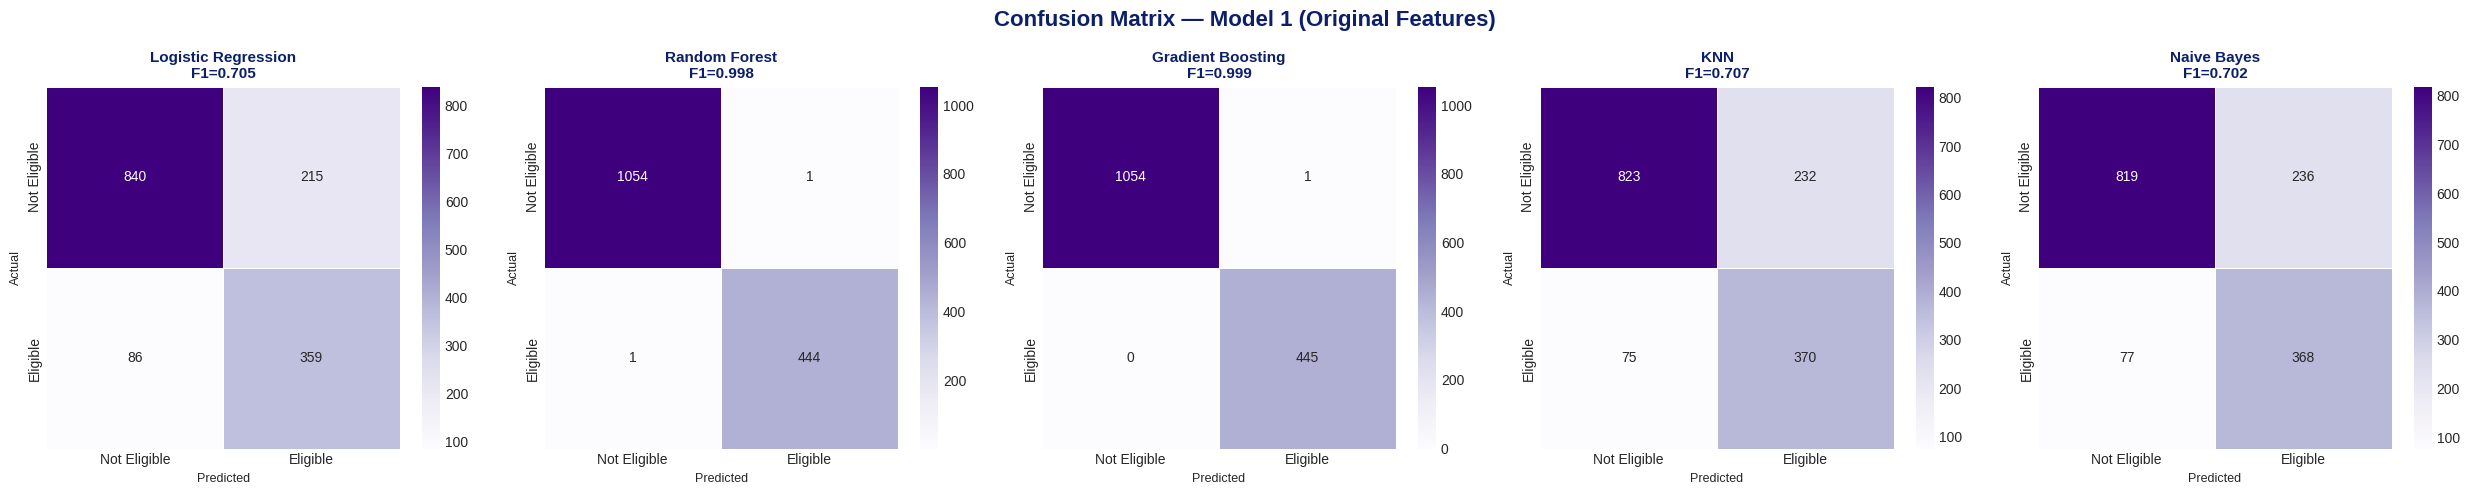

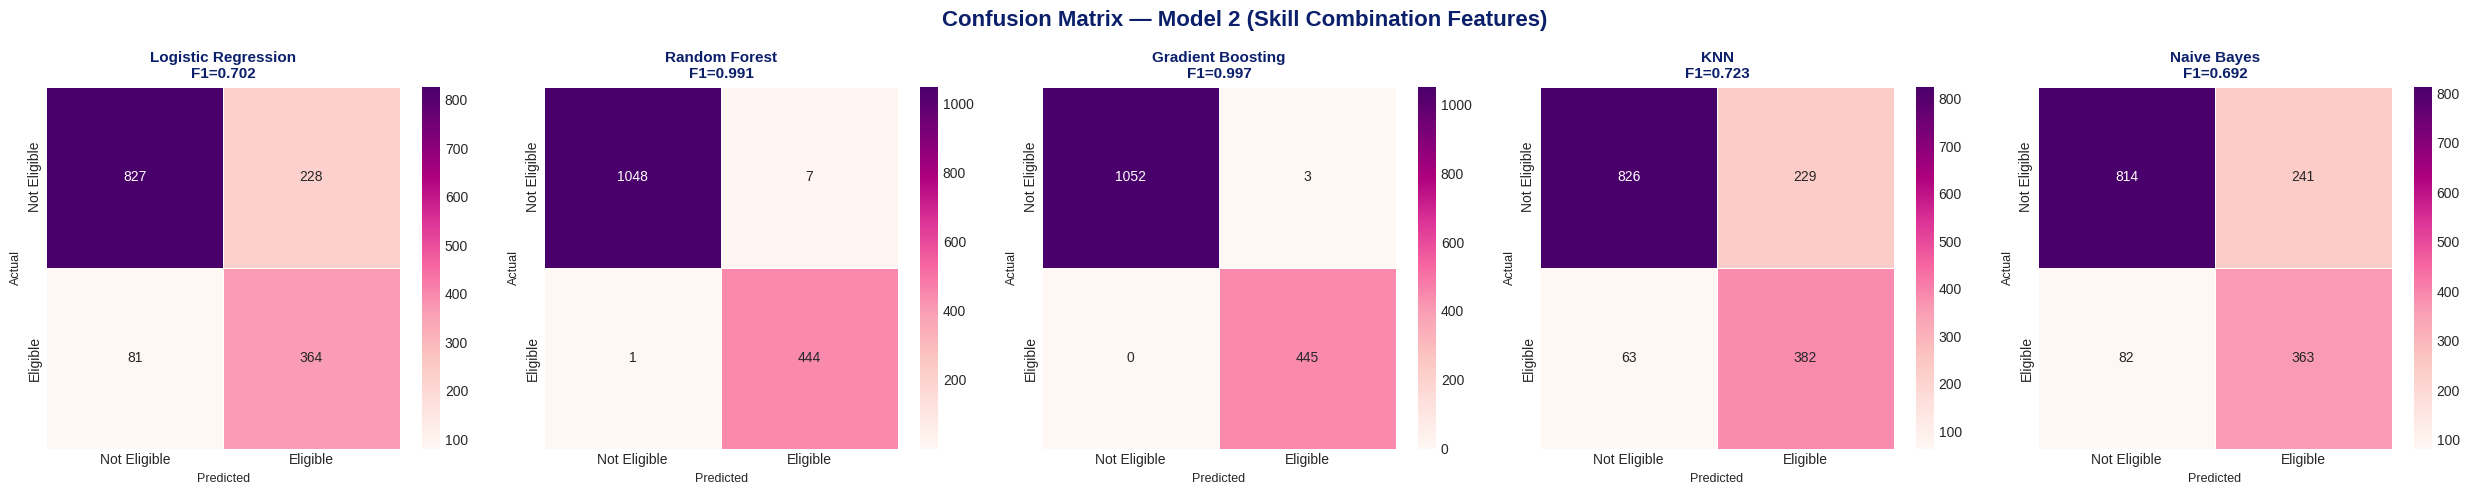

✅ Confusion matrix disimpan!


In [35]:
# ============================================================
# CONFUSION MATRIX — Semua Model (Model 1)
# ============================================================

fig, axes = plt.subplots(1, 5, figsize=(25, 5))

for ax, result in zip(axes, results_m1):
    cm = confusion_matrix(y1_test, result['y_pred'])
    sns.heatmap(
        cm, annot=True, fmt='d',
        cmap='Purples',
        xticklabels=['Not Eligible', 'Eligible'],
        yticklabels=['Not Eligible', 'Eligible'],
        ax=ax, linewidths=0.5
    )
    ax.set_title(
        f"{result['name']}\nF1={result['f1']:.3f}",
        fontsize=11, fontweight='bold', color=DARK_BLUE
    )
    ax.set_xlabel('Predicted', fontsize=9)
    ax.set_ylabel('Actual', fontsize=9)

fig.suptitle('Confusion Matrix — Model 1 (Original Features)',
             fontsize=16, fontweight='bold', color=DARK_BLUE)
plt.tight_layout()
plt.savefig('confusion_matrix_model1.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# ---------- Model 2 ----------
fig, axes = plt.subplots(1, 5, figsize=(25, 5))

for ax, result in zip(axes, results_m2):
    cm = confusion_matrix(y2_test, result['y_pred'])
    sns.heatmap(
        cm, annot=True, fmt='d',
        cmap='RdPu',
        xticklabels=['Not Eligible', 'Eligible'],
        yticklabels=['Not Eligible', 'Eligible'],
        ax=ax, linewidths=0.5
    )
    ax.set_title(
        f"{result['name']}\nF1={result['f1']:.3f}",
        fontsize=11, fontweight='bold', color=DARK_BLUE
    )
    ax.set_xlabel('Predicted', fontsize=9)
    ax.set_ylabel('Actual', fontsize=9)

fig.suptitle('Confusion Matrix — Model 2 (Skill Combination Features)',
             fontsize=16, fontweight='bold', color=DARK_BLUE)
plt.tight_layout()
plt.savefig('confusion_matrix_model2.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('✅ Confusion matrix disimpan!')

In [36]:
# ============================================================
# A.6 FINAL TEST EVALUATION
# Test set digunakan setelah model final dikunci
# ============================================================

import pandas as pd

from sklearn.base import clone
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

# Mengambil model terbaik dari tuning
final_gb_model = clone(grid_search_gb.best_estimator_)

# Melatih model pada seluruh training set (menggunakan data training hasil SMOTE)
final_gb_model.fit(
    X1_train_smote,
    y1_train_smote
)

# Prediksi kelas dan probabilitas pada final test set
y_test_pred = final_gb_model.predict(X1_test_scaled)
y_test_proba = final_gb_model.predict_proba(X1_test_scaled)[:, 1]

# Menghitung metrik final
final_test_metrics = pd.DataFrame({
    "Metric": [
        "Test Accuracy",
        "Test Precision",
        "Test Recall",
        "Test F1",
        "Test F2",
        "Test ROC-AUC"
    ],
    "Score": [
        accuracy_score(y1_test, y_test_pred),
        precision_score(
            y1_test,
            y_test_pred,
            zero_division=0
        ),
        recall_score(
            y1_test,
            y_test_pred,
            zero_division=0
        ),
        f1_score(
            y1_test,
            y_test_pred,
            zero_division=0
        ),
        fbeta_score(
            y1_test,
            y_test_pred,
            beta=2,
            zero_division=0
        ),
        roc_auc_score(
            y1_test,
            y_test_proba
        )
    ]
})

final_test_metrics["Score"] = (
    final_test_metrics["Score"].round(4)
)

print("===== FINAL TEST RESULT =====")
print(final_test_metrics.to_string(index=False))

print("\n===== CLASSIFICATION REPORT =====")
print(
    classification_report(
        y1_test,
        y_test_pred,
        target_names=[
            "Not Eligible",
            "Eligible"
        ],
        digits=4,
        zero_division=0
    )
)

print("===== CONFUSION MATRIX =====")
print(
    confusion_matrix(
        y1_test,
        y_test_pred
    )
)

===== FINAL TEST RESULT =====
        Metric  Score
 Test Accuracy 0.9993
Test Precision 0.9978
   Test Recall 1.0000
       Test F1 0.9989
       Test F2 0.9996
  Test ROC-AUC 1.0000

===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

Not Eligible     1.0000    0.9991    0.9995      1055
    Eligible     0.9978    1.0000    0.9989       445

    accuracy                         0.9993      1500
   macro avg     0.9989    0.9995    0.9992      1500
weighted avg     0.9993    0.9993    0.9993      1500

===== CONFUSION MATRIX =====
[[1054    1]
 [   0  445]]


## **A6. CLASSIFICATION REPORT — Model Terbaik**

In [37]:
# ============================================================
# A6. CLASSIFICATION REPORT — Model Terbaik
# ============================================================

# Tentukan model terbaik berdasarkan F1-Score
best_m1 = max(results_m1, key=lambda r: r['f1'])
best_m2 = max(results_m2, key=lambda r: r['f1'])

print(f'🏆 Model Terbaik (Model 1): {best_m1["name"]} — F1={best_m1["f1"]:.4f}')
print(f'🏆 Model Terbaik (Model 2): {best_m2["name"]} — F1={best_m2["f1"]:.4f}')

print()
print('='*60)
print(f'CLASSIFICATION REPORT — {best_m1["name"]} (Model 1)')
print('='*60)
print(classification_report(
    y1_test, best_m1['y_pred'],
    target_names=['Not Eligible', 'Eligible']
))

print('='*60)
print(f'CLASSIFICATION REPORT — {best_m2["name"]} (Model 2)')
print('='*60)
print(classification_report(
    y2_test, best_m2['y_pred'],
    target_names=['Not Eligible', 'Eligible']
))

🏆 Model Terbaik (Model 1): Gradient Boosting — F1=0.9989
🏆 Model Terbaik (Model 2): Gradient Boosting — F1=0.9966

CLASSIFICATION REPORT — Gradient Boosting (Model 1)
              precision    recall  f1-score   support

Not Eligible       1.00      1.00      1.00      1055
    Eligible       1.00      1.00      1.00       445

    accuracy                           1.00      1500
   macro avg       1.00      1.00      1.00      1500
weighted avg       1.00      1.00      1.00      1500

CLASSIFICATION REPORT — Gradient Boosting (Model 2)
              precision    recall  f1-score   support

Not Eligible       1.00      1.00      1.00      1055
    Eligible       0.99      1.00      1.00       445

    accuracy                           1.00      1500
   macro avg       1.00      1.00      1.00      1500
weighted avg       1.00      1.00      1.00      1500



### **ROC CURVE — Semua Model**

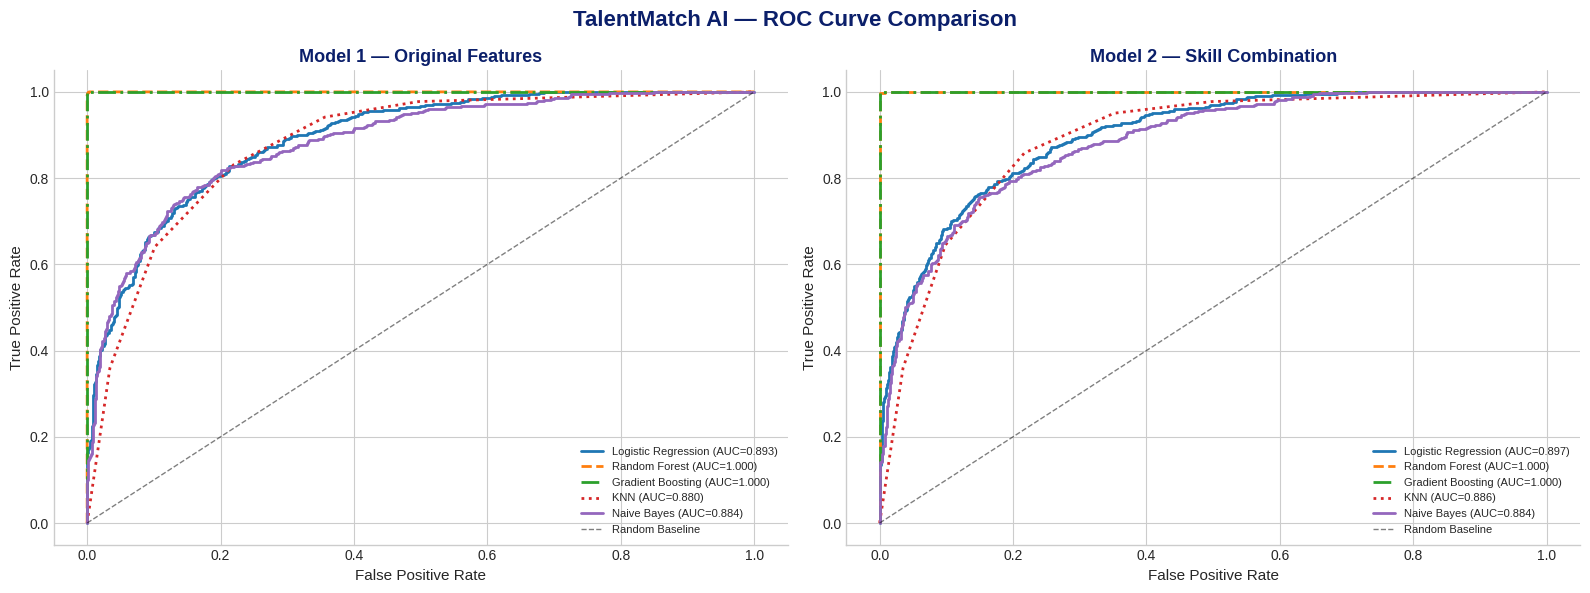

✅ ROC Curve disimpan: roc_curve_comparison.png


In [38]:
# ============================================================
# ROC CURVE — Semua Model
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
line_styles = ['-', '--', '-.', ':', '-']

for ax, results, y_test, title in zip(
    axes,
    [results_m1, results_m2],
    [y1_test, y2_test],
    ['Model 1 — Original Features', 'Model 2 — Skill Combination']
):
    for i, result in enumerate(results):
        fpr, tpr, _ = roc_curve(y_test, result['y_prob'])
        ax.plot(
            fpr, tpr,
            linestyle=line_styles[i],
            linewidth=2,
            label=f"{result['name']} (AUC={result['roc_auc']:.3f})"
        )

    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random Baseline')
    ax.set_xlabel('False Positive Rate', fontsize=11)
    ax.set_ylabel('True Positive Rate', fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold', color=DARK_BLUE)
    ax.legend(fontsize=8, loc='lower right')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('TalentMatch AI — ROC Curve Comparison',
             fontsize=16, fontweight='bold', color=DARK_BLUE)
plt.tight_layout()
plt.savefig('roc_curve_comparison.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('✅ ROC Curve disimpan: roc_curve_comparison.png')

## **A7. MENENTUKAN MODEL TERBAIK OVERALL**

In [39]:
import pandas as pd

# ============================================================
# A7. MENENTUKAN MODEL TERBAIK OVERALL
# ============================================================

all_results = []
for r in results_m1:
    d = {k: v for k, v in r.items() if k != 'model'}
    d['feature_set'] = 'Model 1'
    d['model_key']   = f"{r['name']} (M1)"
    all_results.append(d)
for r in results_m2:
    d = {k: v for k, v in r.items() if k != 'model'}
    d['feature_set'] = 'Model 2'
    d['model_key']   = f"{r['name']} (M2)"
    all_results.append(d)

df_all = pd.DataFrame(all_results)
# Composite score: rata-rata F1 & ROC-AUC
df_all['composite'] = (df_all['f1'] + df_all['roc_auc']) / 2
df_all_sorted = df_all.sort_values('composite', ascending=False)

print('='*60)
print('  RANKING MODEL BERDASARKAN COMPOSITE SCORE (F1 + ROC-AUC)')
print('='*60)
display(df_all_sorted[['model_key', 'feature_set', 'accuracy', 'precision',
                         'recall', 'f1', 'roc_auc', 'composite']]
        .set_index('model_key')
        .style.format('{:.4f}', subset=['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'composite'])
       )

best_overall = df_all_sorted.iloc[0]
print(f'\n🏆 MODEL TERBAIK OVERALL: {best_overall["model_key"]}')
print(f'   Composite Score : {best_overall["composite"]:.4f}')
print(f'   F1-Score        : {best_overall["f1"]:.4f}')
print(f'   ROC-AUC         : {best_overall["roc_auc"]:.4f}')

  RANKING MODEL BERDASARKAN COMPOSITE SCORE (F1 + ROC-AUC)


,feature_set,accuracy,precision,recall,f1,roc_auc,composite
model_key,,,,,,,
Gradient Boosting (M1),Model 1,0.9993,0.9978,1.0000,0.9989,1.0000,0.9994
Random Forest (M1),Model 1,0.9987,0.9978,0.9978,0.9978,1.0000,0.9989
Gradient Boosting (M2),Model 2,0.9980,0.9933,1.0000,0.9966,1.0000,0.9983
Random Forest (M2),Model 2,0.9947,0.9845,0.9978,0.9911,1.0000,0.9955
KNN (M2),Model 2,0.8053,0.6252,0.8584,0.7235,0.8865,0.8050
Logistic Regression (M2),Model 2,0.7940,0.6149,0.8180,0.7020,0.8973,0.7996
Logistic Regression (M1),Model 1,0.7993,0.6254,0.8067,0.7046,0.8928,0.7987
KNN (M1),Model 1,0.7953,0.6146,0.8315,0.7068,0.8803,0.7935
Naive Bayes (M1),Model 1,0.7913,0.6093,0.8270,0.7016,0.8845,0.7931



🏆 MODEL TERBAIK OVERALL: Gradient Boosting (M1)
   Composite Score : 0.9994
   F1-Score        : 0.9989
   ROC-AUC         : 1.0000


## **A8. INTERPRETASI KEKUATAN & KELEMAHAN MODEL**

In [40]:
# ============================================================
# A8. INTERPRETASI KEKUATAN & KELEMAHAN MODEL
# ============================================================

interpretation = {
    'Logistic Regression': {
        'Kekuatan': ['Mudah diinterpretasikan oleh HR', 'Probabilitas keputusan jelas', 'Tidak mudah overfit'],
        'Kelemahan': ['Tidak menangkap hubungan non-linear', 'Performa bisa lebih rendah jika fitur kompleks']
    },
    'Random Forest': {
        'Kekuatan': ['Robust terhadap outlier', 'Menangkap hubungan non-linear', 'Feature importance tersedia'],
        'Kelemahan': ['Sulit diinterpretasikan langsung', 'Waktu training lebih lama']
    },
    'Gradient Boosting': {
        'Kekuatan': ['Performa tinggi', 'Menangkap interaksi fitur kompleks', 'Feature importance tersedia'],
        'Kelemahan': ['Rentan overfit jika tidak di-tune', 'Interpretabilitas rendah']
    },
    'KNN': {
        'Kekuatan': ['Sederhana dan intuitif', 'Non-parametrik'],
        'Kelemahan': ['Lambat pada data besar', 'Sensitif terhadap skala fitur dan K']
    },
    'Naive Bayes': {
        'Kekuatan': ['Sangat cepat', 'Baik untuk baseline'],
        'Kelemahan': ['Asumsi independensi fitur sering tidak terpenuhi', 'Performa bisa rendah']
    }
}

print('='*60)
print('  INTERPRETASI KEKUATAN & KELEMAHAN MODEL')
print('='*60)
for model_name, info in interpretation.items():
    print(f'\n🔹 {model_name}')
    print(f'   ✅ Kekuatan  : {", ".join(info["Kekuatan"])}')
    print(f'   ❌ Kelemahan : {", ".join(info["Kelemahan"])}')

  INTERPRETASI KEKUATAN & KELEMAHAN MODEL

🔹 Logistic Regression
   ✅ Kekuatan  : Mudah diinterpretasikan oleh HR, Probabilitas keputusan jelas, Tidak mudah overfit
   ❌ Kelemahan : Tidak menangkap hubungan non-linear, Performa bisa lebih rendah jika fitur kompleks

🔹 Random Forest
   ✅ Kekuatan  : Robust terhadap outlier, Menangkap hubungan non-linear, Feature importance tersedia
   ❌ Kelemahan : Sulit diinterpretasikan langsung, Waktu training lebih lama

🔹 Gradient Boosting
   ✅ Kekuatan  : Performa tinggi, Menangkap interaksi fitur kompleks, Feature importance tersedia
   ❌ Kelemahan : Rentan overfit jika tidak di-tune, Interpretabilitas rendah

🔹 KNN
   ✅ Kekuatan  : Sederhana dan intuitif, Non-parametrik
   ❌ Kelemahan : Lambat pada data besar, Sensitif terhadap skala fitur dan K

🔹 Naive Bayes
   ✅ Kekuatan  : Sangat cepat, Baik untuk baseline
   ❌ Kelemahan : Asumsi independensi fitur sering tidak terpenuhi, Performa bisa rendah


---
## 🔍 B. EXPLAINABILITY & FAIRNESS ANALYSIS
### B1. Feature Importance — Model Terbaik

## **B1. FEATURE IMPORTANCE — Random Forest & Gradient Boosting**

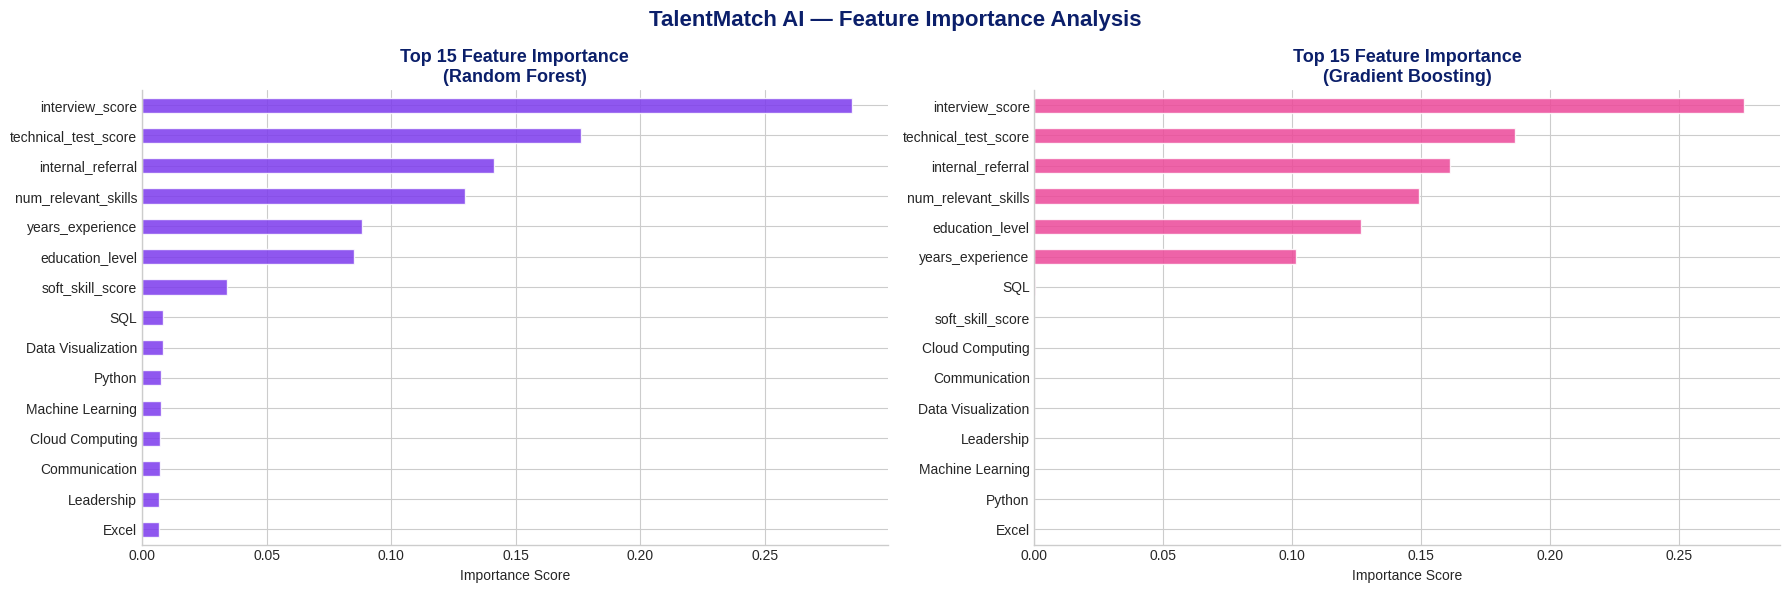

✅ Feature importance disimpan: feature_importance.png


In [41]:
# ============================================================
# B1. FEATURE IMPORTANCE — Random Forest & Gradient Boosting
# ============================================================

# Ambil RF dan GB dari Model 1
rf_result  = next(r for r in results_m1 if r['name'] == 'Random Forest')
gb_result  = next(r for r in results_m1 if r['name'] == 'Gradient Boosting')

feature_names = X1.columns.tolist()

# Feature importances
rf_importance = pd.Series(rf_result['model'].feature_importances_, index=feature_names)
gb_importance = pd.Series(gb_result['model'].feature_importances_, index=feature_names)

top_n = 15
rf_top = rf_importance.nlargest(top_n)
gb_top = gb_importance.nlargest(top_n)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for ax, importance, name, color in zip(
    axes,
    [rf_top, gb_top],
    ['Random Forest', 'Gradient Boosting'],
    [PRIMARY, SECONDARY]
):
    importance.sort_values().plot(
        kind='barh', ax=ax, color=color, alpha=0.85, edgecolor='white'
    )
    ax.set_title(f'Top {top_n} Feature Importance\n({name})',
                 fontsize=13, fontweight='bold', color=DARK_BLUE)
    ax.set_xlabel('Importance Score')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('TalentMatch AI — Feature Importance Analysis',
             fontsize=16, fontweight='bold', color=DARK_BLUE)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('✅ Feature importance disimpan: feature_importance.png')

## **B2. SHAP ANALYSIS — Gradient Boosting Model 1**

Menghitung SHAP values...


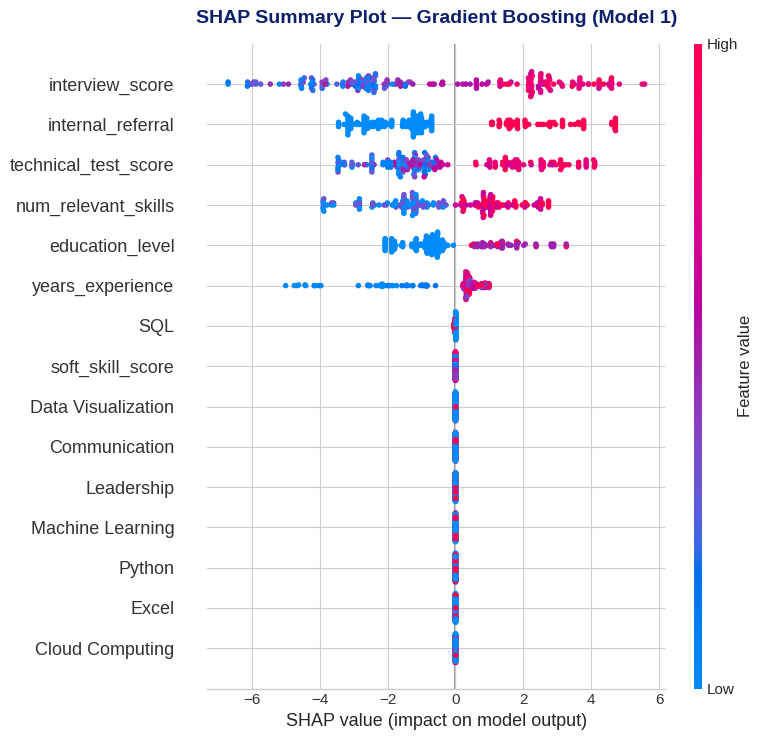

✅ SHAP summary disimpan: shap_summary.png


In [42]:
# ============================================================
# B2. SHAP ANALYSIS — Gradient Boosting Model 1
# ============================================================

print('Menghitung SHAP values...')

# Gunakan sample agar lebih cepat
X1_test_sample = X1_test_scaled[:200]

explainer_shap = shap.TreeExplainer(gb_result['model'])
shap_values    = explainer_shap.shap_values(X1_test_sample)

# Jika output adalah list (multi-class), ambil class 1 (Eligible)
if isinstance(shap_values, list):
    sv = shap_values[1]
else:
    sv = shap_values

# --- SHAP Summary Plot ---
plt.figure(figsize=(12, 7))
shap.summary_plot(
    sv,
    X1_test_sample,
    feature_names=feature_names,
    plot_type='dot',
    show=False,
    max_display=15
)
plt.title('SHAP Summary Plot — Gradient Boosting (Model 1)',
          fontsize=14, fontweight='bold', color=DARK_BLUE, pad=15)
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('✅ SHAP summary disimpan: shap_summary.png')

### **SHAP BAR PLOT — Mean Absolute SHAP Values**

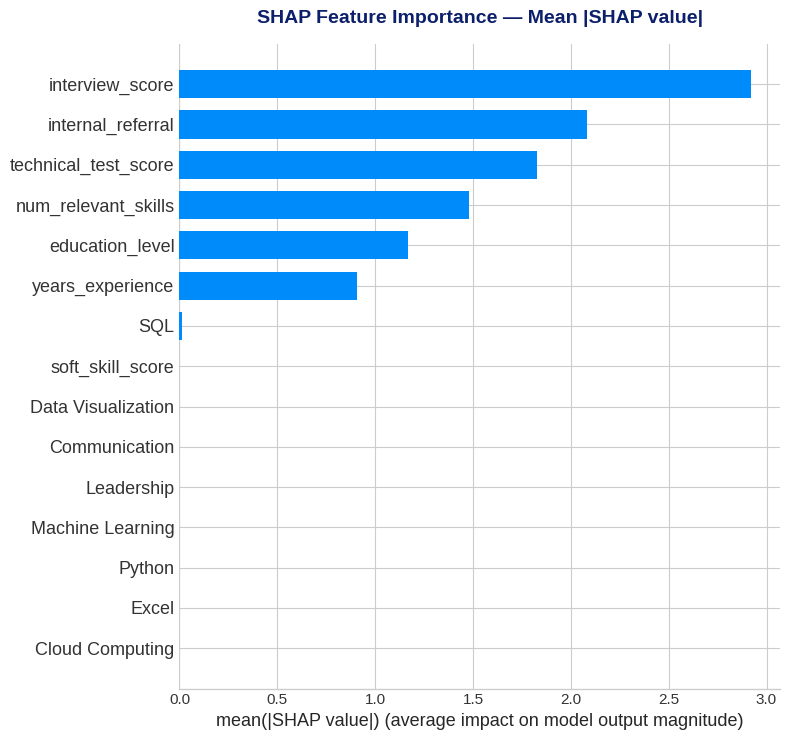

✅ SHAP bar disimpan: shap_bar.png


In [43]:
# ============================================================
# SHAP BAR PLOT — Mean Absolute SHAP Values
# ============================================================

plt.figure(figsize=(10, 6))
shap.summary_plot(
    sv,
    X1_test_sample,
    feature_names=feature_names,
    plot_type='bar',
    show=False,
    max_display=15
)
plt.title('SHAP Feature Importance — Mean |SHAP value|',
          fontsize=14, fontweight='bold', color=DARK_BLUE, pad=15)
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('✅ SHAP bar disimpan: shap_bar.png')

### **SHAP WATERFALL — Contoh Prediksi Individ**

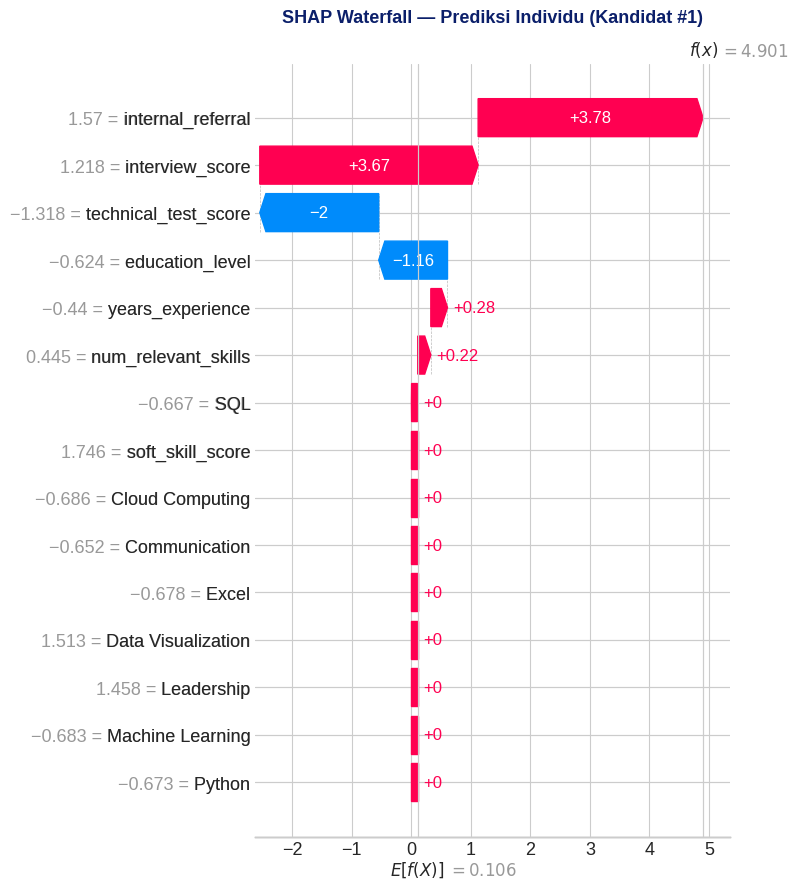

✅ SHAP waterfall disimpan: shap_waterfall.png


In [44]:
# ============================================================
# SHAP WATERFALL — Contoh Prediksi Individu
# ============================================================

# Contoh kandidat pertama
shap_exp = shap.Explanation(
    values=sv[0],
    base_values=explainer_shap.expected_value[1] if isinstance(explainer_shap.expected_value, list)
                else explainer_shap.expected_value,
    data=X1_test_sample[0],
    feature_names=feature_names
)

plt.figure(figsize=(10, 6))
shap.waterfall_plot(shap_exp, max_display=15, show=False)
plt.title('SHAP Waterfall — Prediksi Individu (Kandidat #1)',
          fontsize=13, fontweight='bold', color=DARK_BLUE, pad=12)
plt.tight_layout()
plt.savefig('shap_waterfall.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('✅ SHAP waterfall disimpan: shap_waterfall.png')

## **B3. LIME — Penjelasan Lokal 1 Kandidat**


📌 Case yang Dijelaskan: Kandidat Pertama
   Actual  : Eligible
   Prediksi: Eligible


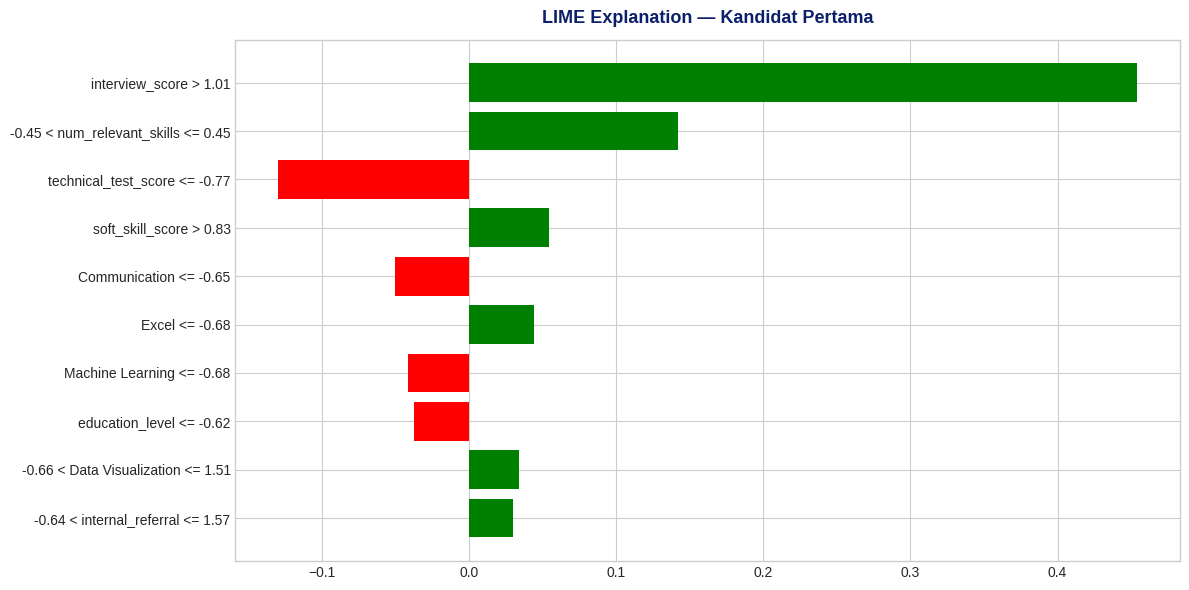

✅ LIME explanation disimpan: lime_explanation.png


In [45]:
# ============================================================
# B3. LIME — Penjelasan Lokal 1 Kandidat
# ============================================================

lime_explainer = LimeTabularExplainer(
    training_data  = X1_train_smote,
    feature_names  = feature_names,
    class_names    = ['Not Eligible', 'Eligible'],
    mode           = 'classification',
    random_state   = 42
)

# Pilih kandidat: ambil False Negative pertama (jika ada)
y_pred_arr  = gb_result['y_pred']
y_test_arr  = y1_test.values
fn_indices  = np.where((y_test_arr == 1) & (y_pred_arr == 0))[0]

if len(fn_indices) > 0:
    idx_explain = fn_indices[0]
    case_label  = '❌ False Negative (Eligible diprediksi Not Eligible)'
else:
    idx_explain = 0
    case_label  = 'Kandidat Pertama'

lime_exp = lime_explainer.explain_instance(
    data_row       = X1_test_scaled[idx_explain],
    predict_fn     = gb_result['model'].predict_proba,
    num_features   = 10,
    num_samples    = 500
)

print(f'\n📌 Case yang Dijelaskan: {case_label}')
print(f'   Actual  : {"Eligible" if y_test_arr[idx_explain] == 1 else "Not Eligible"}')
print(f'   Prediksi: {"Eligible" if y_pred_arr[idx_explain] == 1 else "Not Eligible"}')

# Tampilkan LIME sebagai figure
fig = lime_exp.as_pyplot_figure(label=1)
fig.set_size_inches(12, 6)
plt.title(f'LIME Explanation — {case_label}',
          fontsize=13, fontweight='bold', color=DARK_BLUE, pad=12)
plt.tight_layout()
plt.savefig('lime_explanation.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('✅ LIME explanation disimpan: lime_explanation.png')

## **B4. FAIRNESS & BIAS ANALYSIS**

In [46]:
# ============================================================
# B4. FAIRNESS & BIAS ANALYSIS
# ============================================================

# Gabungkan prediksi dengan data asli untuk analisis fairness
X1_test_df = X1_test.copy().reset_index(drop=True)
fairness_df = X1_test_df.copy()
fairness_df['actual']    = y1_test.values
fairness_df['predicted'] = gb_result['y_pred']
fairness_df['correct']   = (fairness_df['actual'] == fairness_df['predicted']).astype(int)

# --- Fairness berdasarkan Education Level ---
edu_map  = {v: k for k, v in enumerate(le_edu.classes_)}
edu_labels = le_edu.classes_

fairness_edu = fairness_df.groupby('education_level').agg(
    total=('actual', 'count'),
    eligible_actual=('actual', 'sum'),
    eligible_predicted=('predicted', 'sum'),
    accuracy=('correct', 'mean')
).round(4)
fairness_edu['eligible_rate_actual']    = (fairness_edu['eligible_actual'] / fairness_edu['total']).round(4)
fairness_edu['eligible_rate_predicted'] = (fairness_edu['eligible_predicted'] / fairness_edu['total']).round(4)
fairness_edu.index = [edu_labels[int(i)] if int(i) < len(edu_labels) else i for i in fairness_edu.index]

print('='*60)
print('  FAIRNESS ANALYSIS — Education Level')
print('='*60)
display(fairness_edu.style.format({'accuracy': '{:.4f}', 'eligible_rate_actual': '{:.4f}',
                                    'eligible_rate_predicted': '{:.4f}'}))

# --- Fairness berdasarkan Internal Referral ---
fairness_ref = fairness_df.groupby('internal_referral').agg(
    total=('actual', 'count'),
    eligible_actual=('actual', 'sum'),
    eligible_predicted=('predicted', 'sum'),
    accuracy=('correct', 'mean')
).round(4)
fairness_ref.index = le_ref.inverse_transform(fairness_ref.index.astype(int).tolist())

print()
print('='*60)
print('  FAIRNESS ANALYSIS — Internal Referral')
print('='*60)
display(fairness_ref.style.format('{:.4f}'))

  FAIRNESS ANALYSIS — Education Level


,total,eligible_actual,eligible_predicted,accuracy,eligible_rate_actual,eligible_rate_predicted
Bachelor,1050,252,253,0.9990,0.2400,0.2410
Master,384,163,163,1.0000,0.4245,0.4245
PhD,66,30,30,1.0000,0.4545,0.4545



  FAIRNESS ANALYSIS — Internal Referral


,total,eligible_actual,eligible_predicted,accuracy
No,1039.0000,226.0000,226.0000,1.0000
Yes,461.0000,219.0000,220.0000,0.9978


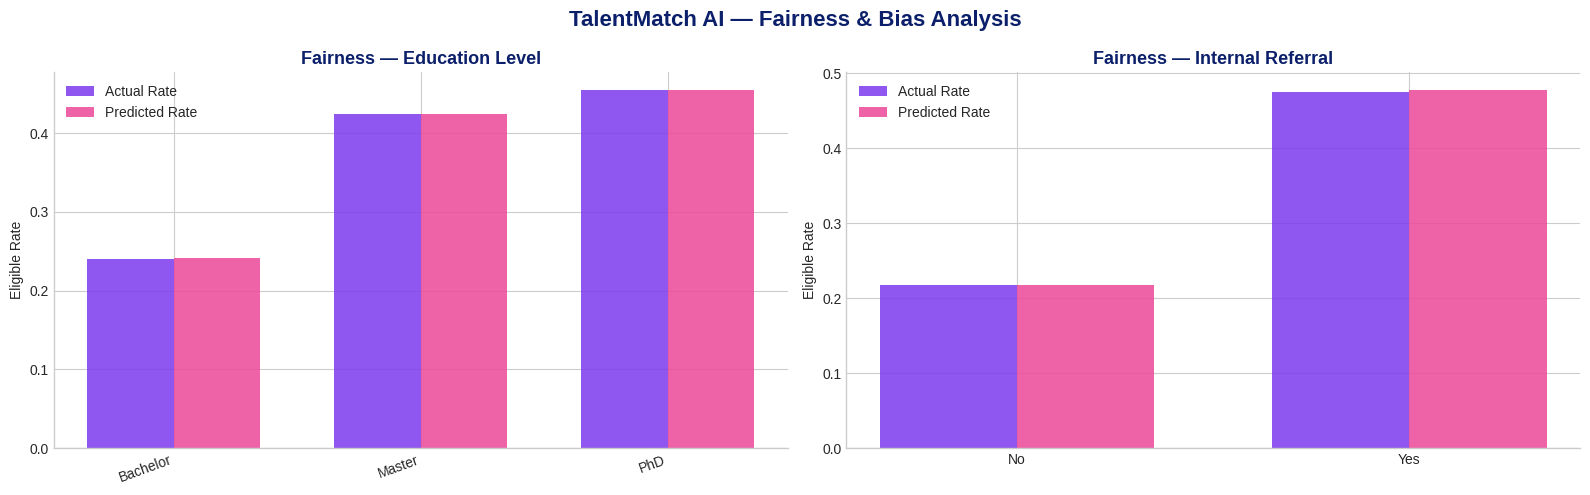

✅ Fairness analysis disimpan: fairness_analysis.png


In [47]:
# ============================================================
# VISUALISASI FAIRNESS — Eligible Rate Actual vs Predicted
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Education Level
ax = axes[0]
x  = np.arange(len(fairness_edu))
w  = 0.35
ax.bar(x - w/2, fairness_edu['eligible_rate_actual'],   w, label='Actual Rate',    color=PRIMARY,   alpha=0.85)
ax.bar(x + w/2, fairness_edu['eligible_rate_predicted'], w, label='Predicted Rate', color=SECONDARY, alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(fairness_edu.index, rotation=20, ha='right')
ax.set_title('Fairness — Education Level', fontsize=13, fontweight='bold', color=DARK_BLUE)
ax.set_ylabel('Eligible Rate')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Internal Referral
ax = axes[1]
x  = np.arange(len(fairness_ref))
ax.bar(x - w/2, fairness_ref['eligible_actual'] / fairness_ref['total'],   w, label='Actual Rate',    color=PRIMARY,   alpha=0.85)
ax.bar(x + w/2, fairness_ref['eligible_predicted'] / fairness_ref['total'], w, label='Predicted Rate', color=SECONDARY, alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(fairness_ref.index)
ax.set_title('Fairness — Internal Referral', fontsize=13, fontweight='bold', color=DARK_BLUE)
ax.set_ylabel('Eligible Rate')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.suptitle('TalentMatch AI — Fairness & Bias Analysis',
             fontsize=16, fontweight='bold', color=DARK_BLUE)
plt.tight_layout()
plt.savefig('fairness_analysis.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('✅ Fairness analysis disimpan: fairness_analysis.png')

---
## 💼 C. ERROR ANALYSIS & BUSINESS IMPACT ASSESSMENT
### C1. Analisis False Positive & False Negative

## **C1. ERROR ANALYSIS — False Positive & False Negative**

In [48]:
# ============================================================
# C1. ERROR ANALYSIS — False Positive & False Negative
# ============================================================

# Gunakan model terbaik (Gradient Boosting, Model 1)
error_df = X1_test.copy().reset_index(drop=True)
error_df['actual']    = y1_test.values
error_df['predicted'] = gb_result['y_pred']
error_df['prob']      = gb_result['y_prob']

error_df['error_type'] = 'True'
error_df.loc[(error_df['actual'] == 0) & (error_df['predicted'] == 1), 'error_type'] = 'False Positive'
error_df.loc[(error_df['actual'] == 1) & (error_df['predicted'] == 0), 'error_type'] = 'False Negative'
error_df.loc[(error_df['actual'] == 1) & (error_df['predicted'] == 1), 'error_type'] = 'True Positive'
error_df.loc[(error_df['actual'] == 0) & (error_df['predicted'] == 0), 'error_type'] = 'True Negative'

# Count
error_counts = error_df['error_type'].value_counts().reset_index()
error_counts.columns = ['Type', 'Count']

print('='*50)
print('  DISTRIBUSI PREDIKSI — Gradient Boosting (M1)')
print('='*50)
display(error_counts)

fp_df = error_df[error_df['error_type'] == 'False Positive']
fn_df = error_df[error_df['error_type'] == 'False Negative']

print(f'\n📌 False Positive  : {len(fp_df)} kandidat')
print(f'   → Diprediksi Eligible, PADAHAL Not Eligible')
print(f'   → Risiko: HR membuang waktu mewawancarai kandidat tidak layak\n')

print(f'📌 False Negative  : {len(fn_df)} kandidat')
print(f'   → Diprediksi Not Eligible, PADAHAL sebenarnya Eligible')
print(f'   → Risiko: Melewatkan kandidat terbaik, kehilangan talent potensial')

  DISTRIBUSI PREDIKSI — Gradient Boosting (M1)


,Type,Count
0,True Negative,1054
1,True Positive,445
2,False Positive,1



📌 False Positive  : 1 kandidat
   → Diprediksi Eligible, PADAHAL Not Eligible
   → Risiko: HR membuang waktu mewawancarai kandidat tidak layak

📌 False Negative  : 0 kandidat
   → Diprediksi Not Eligible, PADAHAL sebenarnya Eligible
   → Risiko: Melewatkan kandidat terbaik, kehilangan talent potensial


## **C2. KARAKTERISTIK KANDIDAT YANG SALAH DIPREDIKSI**

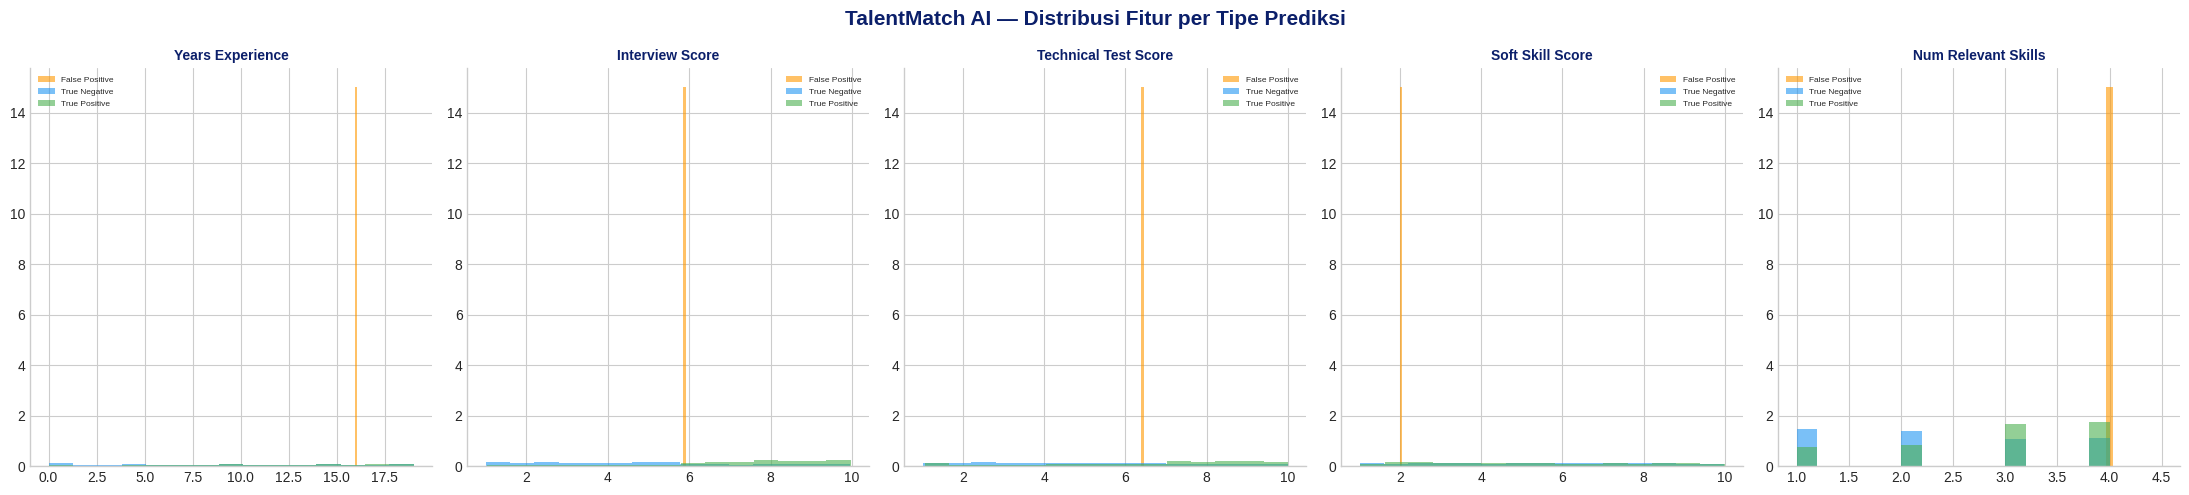

✅ Error analysis feature disimpan!


In [49]:
# ============================================================
# C2. KARAKTERISTIK KANDIDAT YANG SALAH DIPREDIKSI
# ============================================================

num_features_plot = ['years_experience', 'interview_score',
                     'technical_test_score', 'soft_skill_score', 'num_relevant_skills']

# Filter fitur yang tersedia
num_features_plot = [f for f in num_features_plot if f in error_df.columns]

fig, axes = plt.subplots(1, len(num_features_plot), figsize=(22, 5))

color_map = {
    'True Positive' : '#4CAF50',
    'True Negative' : '#2196F3',
    'False Positive': '#FF9800',
    'False Negative': '#F44336'
}

for ax, feat in zip(axes, num_features_plot):
    for etype, grp in error_df.groupby('error_type'):
        ax.hist(
            grp[feat].dropna(), bins=15, alpha=0.6,
            label=etype, color=color_map.get(etype, 'grey'), density=True
        )
    ax.set_title(feat.replace('_', ' ').title(), fontsize=10, fontweight='bold', color=DARK_BLUE)
    ax.set_xlabel('')
    ax.legend(fontsize=6)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('TalentMatch AI — Distribusi Fitur per Tipe Prediksi',
             fontsize=15, fontweight='bold', color=DARK_BLUE)
plt.tight_layout()
plt.savefig('error_analysis_features.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('✅ Error analysis feature disimpan!')

## **C3. PERBANDINGAN STATISTIK — FP, FN, TP, TN**

In [50]:
# ============================================================
# C3. PERBANDINGAN STATISTIK — FP, FN, TP, TN
# ============================================================

if len(num_features_plot) > 0:
    stat_comparison = error_df.groupby('error_type')[num_features_plot].mean().round(3)

    print('='*70)
    print('  RATA-RATA FITUR BERDASARKAN TIPE PREDIKSI')
    print('='*70)
    display(stat_comparison.style.background_gradient(cmap='RdYlGn', axis=0))

    print()
    print('📌 Insight:')
    print('  - False Negative biasanya kandidat dengan nilai di batas threshold')
    print('  - False Positive biasanya kandidat dengan 1-2 fitur tinggi tapi lainnya rendah')
    print('  - Perhatikan gap antara FP dan TP untuk memahami boundary keputusan model')

  RATA-RATA FITUR BERDASARKAN TIPE PREDIKSI


,years_experience,interview_score,technical_test_score,soft_skill_score,num_relevant_skills
error_type,,,,,
False Positive,16.000000,5.890000,6.420000,2.020000,4.000000
True Negative,9.005000,4.827000,5.051000,5.388000,2.361000
True Positive,11.002000,7.144000,6.554000,5.309000,2.890000



📌 Insight:
  - False Negative biasanya kandidat dengan nilai di batas threshold
  - False Positive biasanya kandidat dengan 1-2 fitur tinggi tapi lainnya rendah
  - Perhatikan gap antara FP dan TP untuk memahami boundary keputusan model


## **C4. FINANCIAL IMPACT — Business Cost Calculation**

In [51]:
# ============================================================
# C4. FINANCIAL IMPACT — Business Cost Calculation
# ============================================================

# Asumsi biaya rekrutmen (referensi industri)
# Rata-rata biaya per hire di Indonesia / perusahaan menengah
COST_PER_INTERVIEW    = 500_000      # Rp 500.000 per sesi wawancara (waktu HR + operasional)
COST_BAD_HIRE         = 30_000_000   # Rp 30 juta (salary 1-3 bulan + onboarding + offboarding)
COST_MISSED_TALENT    = 15_000_000   # Rp 15 juta (kehilangan produktivitas, rekrut ulang)
SALARY_RECRUITER_HOUR = 150_000      # Rp 150.000/jam biaya HR
HOURS_PER_INTERVIEW   = 2            # 2 jam per wawancara

# Jumlah error dari model terbaik (GB, Model 1)
n_fp = len(fp_df)
n_fn = len(fn_df)

# Tanpa AI — asumsikan semi-manual dengan error 30% lebih banyak
n_fp_manual = int(n_fp * 1.30)
n_fn_manual = int(n_fn * 1.30)

# Hitung biaya
def calc_cost(fp, fn):
    cost_fp = fp * (COST_PER_INTERVIEW + COST_BAD_HIRE * 0.1)  # 10% FP berlanjut ke bad hire
    cost_fn = fn * COST_MISSED_TALENT
    cost_interview = fp * HOURS_PER_INTERVIEW * SALARY_RECRUITER_HOUR
    return {
        'Biaya False Positive (wasted interviews)': cost_fp + cost_interview,
        'Biaya False Negative (missed talent)'    : cost_fn,
        'Total Biaya Error'                       : cost_fp + cost_fn + cost_interview
    }

cost_ai     = calc_cost(n_fp, n_fn)
cost_manual = calc_cost(n_fp_manual, n_fn_manual)
savings     = cost_manual['Total Biaya Error'] - cost_ai['Total Biaya Error']

print('='*70)
print('  💰 FINANCIAL IMPACT ANALYSIS (dalam Rupiah)')
print('='*70)
print(f'  Periode: Per batch {len(y1_test)} kandidat (Test Set)\n')

print(f'  📊 Jumlah Error:')
print(f'     False Positive : AI={n_fp} | Manual={n_fp_manual}')
print(f'     False Negative : AI={n_fn} | Manual={n_fn_manual}')
print()
print(f'  {'Komponen':<45} {'Dengan AI':>15} {'Manual/Semi':>15}')
print('  ' + '-'*75)
for key in cost_ai:
    print(f'  {key:<45} Rp {cost_ai[key]:>12,.0f} Rp {cost_manual[key]:>12,.0f}')

print('  ' + '='*75)
print(f'  🏆 PENGHEMATAN DENGAN AI                         Rp {savings:>12,.0f}')
print(f'  💡 Efisiensi Biaya                                       {savings/cost_manual["Total Biaya Error"]*100:.1f}%')

  💰 FINANCIAL IMPACT ANALYSIS (dalam Rupiah)
  Periode: Per batch 1500 kandidat (Test Set)

  📊 Jumlah Error:
     False Positive : AI=1 | Manual=1
     False Negative : AI=0 | Manual=0

  Komponen                                            Dengan AI     Manual/Semi
  ---------------------------------------------------------------------------
  Biaya False Positive (wasted interviews)      Rp    3,800,000 Rp    3,800,000
  Biaya False Negative (missed talent)          Rp            0 Rp            0
  Total Biaya Error                             Rp    3,800,000 Rp    3,800,000
  🏆 PENGHEMATAN DENGAN AI                         Rp            0
  💡 Efisiensi Biaya                                       0.0%


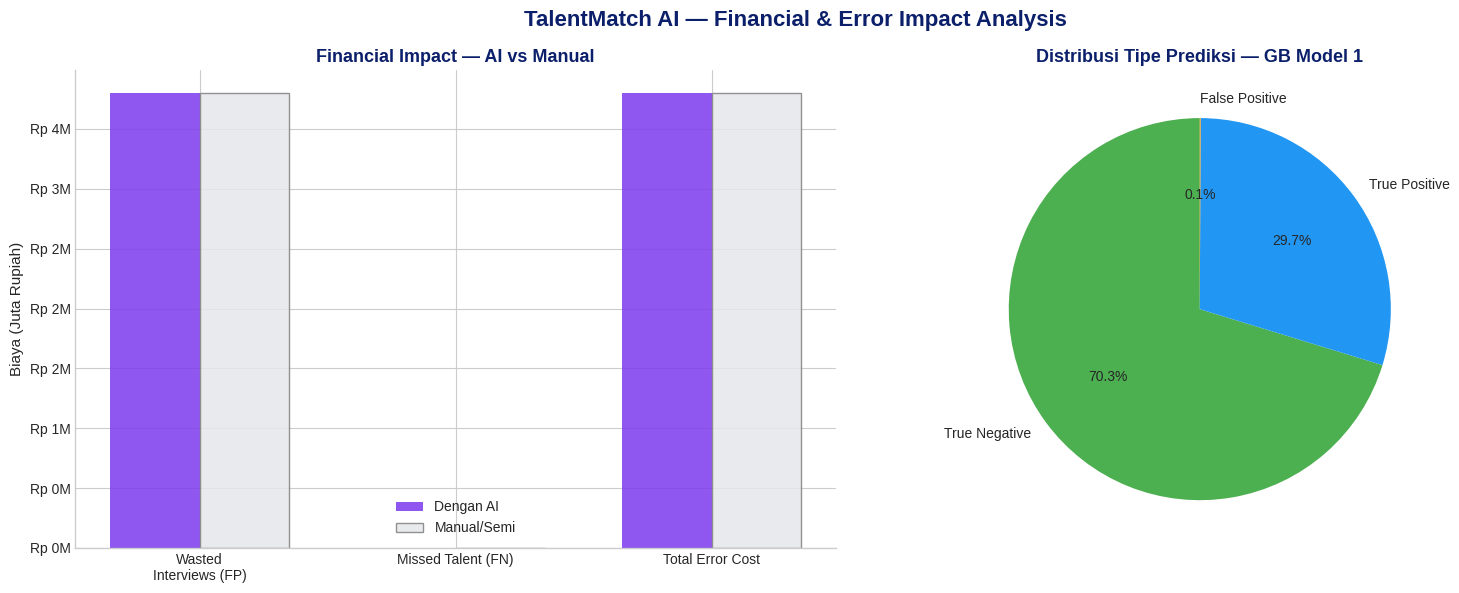

✅ Financial impact disimpan: financial_impact.png


In [52]:
# ============================================================
# VISUALISASI FINANCIAL IMPACT
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Bar Chart: Biaya Perbandingan ---
ax = axes[0]
categories  = ['Wasted\nInterviews (FP)', 'Missed Talent (FN)', 'Total Error Cost']
ai_costs    = [
    cost_ai['Biaya False Positive (wasted interviews)'],
    cost_ai['Biaya False Negative (missed talent)'],
    cost_ai['Total Biaya Error']
]
manual_costs = [
    cost_manual['Biaya False Positive (wasted interviews)'],
    cost_manual['Biaya False Negative (missed talent)'],
    cost_manual['Total Biaya Error']
]

x = np.arange(len(categories))
w = 0.35
ax.bar(x - w/2, [v/1e6 for v in ai_costs],     w, label='Dengan AI',    color=PRIMARY,   alpha=0.85)
ax.bar(x + w/2, [v/1e6 for v in manual_costs],  w, label='Manual/Semi',  color='#E5E7EB', edgecolor='grey', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=10)
ax.set_ylabel('Biaya (Juta Rupiah)', fontsize=11)
ax.set_title('Financial Impact — AI vs Manual', fontsize=13, fontweight='bold', color=DARK_BLUE)
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'Rp {x:.0f}M'))

# --- Pie: Distribusi Error ---
ax = axes[1]
error_type_counts = error_df['error_type'].value_counts()
colors_pie = ['#4CAF50', '#2196F3', '#FF9800', '#F44336']
ax.pie(
    error_type_counts.values,
    labels=error_type_counts.index,
    autopct='%1.1f%%',
    colors=colors_pie[:len(error_type_counts)],
    startangle=90,
    textprops={'fontsize': 10}
)
ax.set_title('Distribusi Tipe Prediksi — GB Model 1',
             fontsize=13, fontweight='bold', color=DARK_BLUE)

fig.suptitle('TalentMatch AI — Financial & Error Impact Analysis',
             fontsize=16, fontweight='bold', color=DARK_BLUE)
plt.tight_layout()
plt.savefig('financial_impact.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('✅ Financial impact disimpan: financial_impact.png')

## **C5. TIME EFFICIENCY — AI vs Manual Recruitment**

  ⏱️ TIME EFFICIENCY ANALYSIS
  Total Kandidat             : 5,000
  Waktu Screening Manual     : 1250 jam (156 hari kerja)
  Waktu Screening dengan AI  : 136.4 jam (17.1 hari kerja)
  Efisiensi Waktu            : 89.1% lebih cepat
  Jam yang Dihemat           : 1114 jam


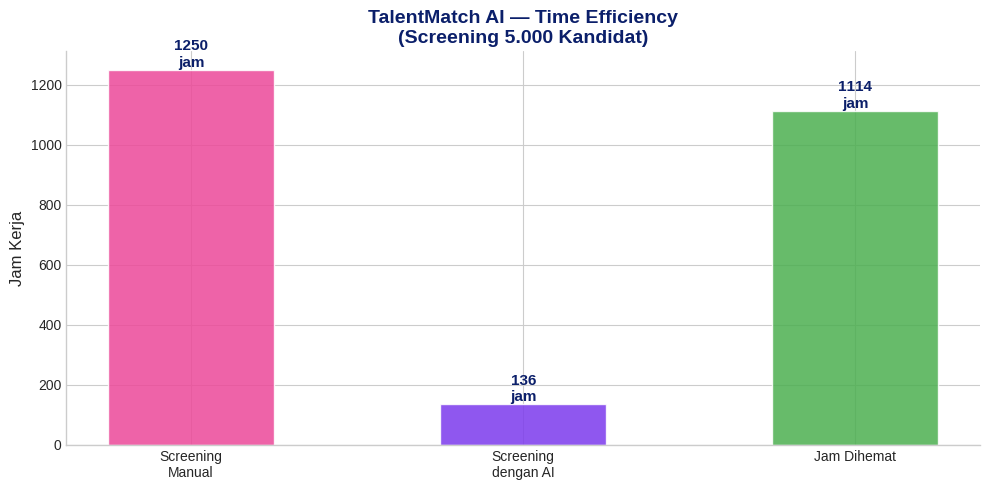

✅ Time efficiency disimpan: time_efficiency.png


In [53]:
# ============================================================
# C5. TIME EFFICIENCY — AI vs Manual Recruitment
# ============================================================

N_CANDIDATES    = 5000       # Total kandidat
SCREEN_MANUAL_H = 0.25       # 15 menit per kandidat (manual screening)
SCREEN_AI_H     = 0.005      # ~30 detik per kandidat (AI scoring)
INTERVIEW_H     = 1.5        # 90 menit per wawancara

# Tanpa AI: semua kandidat perlu di-review manual sebelum shortlist
total_hours_manual = N_CANDIDATES * SCREEN_MANUAL_H
# Dengan AI: hanya shortlist yang perlu di-review
shortlist_pct      = best_m1['precision']  # precision = % yang benar-benar eligible
n_shortlist_ai     = int(N_CANDIDATES * (gb_result['model'].predict(X1_test_scaled).mean()))
total_hours_ai     = N_CANDIDATES * SCREEN_AI_H + n_shortlist_ai * SCREEN_MANUAL_H * 0.3

print('='*60)
print('  ⏱️ TIME EFFICIENCY ANALYSIS')
print('='*60)
print(f'  Total Kandidat             : {N_CANDIDATES:,}')
print(f'  Waktu Screening Manual     : {total_hours_manual:.0f} jam ({total_hours_manual/8:.0f} hari kerja)')
print(f'  Waktu Screening dengan AI  : {total_hours_ai:.1f} jam ({total_hours_ai/8:.1f} hari kerja)')
print(f'  Efisiensi Waktu            : {(1 - total_hours_ai/total_hours_manual)*100:.1f}% lebih cepat')
print(f'  Jam yang Dihemat           : {total_hours_manual - total_hours_ai:.0f} jam')

# Visualisasi
fig, ax = plt.subplots(figsize=(10, 5))

processes = ['Screening\nManual', 'Screening\ndengan AI', 'Jam Dihemat']
hours     = [total_hours_manual, total_hours_ai, total_hours_manual - total_hours_ai]
colors_bar = [SECONDARY, PRIMARY, '#4CAF50']

bars = ax.bar(processes, hours, color=colors_bar, alpha=0.85, width=0.5, edgecolor='white')

for bar, val in zip(bars, hours):
    ax.text(
        bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
        f'{val:.0f}\njam',
        ha='center', fontsize=11, fontweight='bold', color=DARK_BLUE
    )

ax.set_ylabel('Jam Kerja', fontsize=12)
ax.set_title('TalentMatch AI — Time Efficiency\n(Screening 5.000 Kandidat)',
             fontsize=14, fontweight='bold', color=DARK_BLUE)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('time_efficiency.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('✅ Time efficiency disimpan: time_efficiency.png')

---
## 📋 D. SUMMARY, REKOMENDASI & MODEL IMPROVEMENT
### D1. Summary Model Terbaik

In [54]:
# ============================================================
# D1. SUMMARY MODEL TERBAIK
# ============================================================

print('='*70)
print('  🏆 SUMMARY MODEL TERBAIK — TalentMatch AI Stage 3')
print('='*70)
print(f'  Model Terpilih    : {best_overall["model_key"]}')
print(f'  Feature Set       : {best_overall["feature_set"]}')
print()
print(f'  📊 Metrik Performa:')
for m in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
    print(f'     {m.upper():<15}: {best_overall[m]:.4f}')

print()
print(f'  🔍 Interpretasi:')
print(f'     - Model mampu mengidentifikasi {best_overall["recall"]*100:.1f}% kandidat eligible dengan benar (Recall)')
print(f'     - {best_overall["precision"]*100:.1f}% dari kandidat yang diprediksi eligible memang benar eligible (Precision)')
print(f'     - ROC-AUC {best_overall["roc_auc"]:.3f} menunjukkan kemampuan diskriminasi yang {"sangat baik" if best_overall["roc_auc"] > 0.85 else "baik"}')

  🏆 SUMMARY MODEL TERBAIK — TalentMatch AI Stage 3
  Model Terpilih    : Gradient Boosting (M1)
  Feature Set       : Model 1

  📊 Metrik Performa:
     ACCURACY       : 0.9993
     PRECISION      : 0.9978
     RECALL         : 1.0000
     F1             : 0.9989
     ROC_AUC        : 1.0000

  🔍 Interpretasi:
     - Model mampu mengidentifikasi 100.0% kandidat eligible dengan benar (Recall)
     - 99.8% dari kandidat yang diprediksi eligible memang benar eligible (Precision)
     - ROC-AUC 1.000 menunjukkan kemampuan diskriminasi yang sangat baik


In [55]:
# ============================================================
# D2. BUSINESS RECOMMENDATION
# ============================================================

print('='*70)
print('  📌 BUSINESS RECOMMENDATION — TalentMatch AI')
print('='*70)

recommendations = [
    {
        'Prioritas': '🔴 High',
        'Area'     : 'Implementasi AI Screening',
        'Rekomendasi': 'Deploy model Gradient Boosting/Random Forest sebagai tool pre-screening '
                       'kandidat tahap pertama. Tetapkan threshold berdasarkan probabilitas (misal 0.60+) '
                       'bukan hanya biner, agar HR dapat menyortir prioritas kandidat.'
    },
    {
        'Prioritas': '🔴 High',
        'Area'     : 'Mengurangi False Negative',
        'Rekomendasi': f'Saat ini ada {len(fn_df)} kandidat berpotensi baik yang "terlewat". '
                       'Pertimbangkan threshold lebih rendah (misal 0.45) atau menambahkan '
                       'manual review untuk kandidat dengan probabilitas 0.35–0.60 (zona abu-abu).'
    },
    {
        'Prioritas': '🟡 Medium',
        'Area'     : 'Fairness & Bias Monitoring',
        'Rekomendasi': 'Lakukan audit fairness berkala per kuartal. Pastikan model tidak memberikan '
                       'keputusan yang bias berdasarkan education level atau jalur referral. '
                       'Gunakan metrik Equalized Odds atau Demographic Parity untuk monitoring.'
    },
    {
        'Prioritas': '🟡 Medium',
        'Area'     : 'Explainability untuk HR',
        'Rekomendasi': 'Integrasikan SHAP/LIME output ke dalam dashboard HR. Berikan penjelasan '
                       '"mengapa kandidat ini di-shortlist" agar keputusan AI dapat dipahami '
                       'dan divalidasi oleh tim rekrutmen.'
    },
    {
        'Prioritas': '🟢 Low',
        'Area'     : 'Pembaruan Model',
        'Rekomendasi': 'Lakukan retraining model setiap 6 bulan dengan data rekrutmen terbaru. '
                       'Coba XGBoost/LightGBM atau Hyperparameter Tuning (GridSearchCV) '
                       'untuk meningkatkan performa lebih lanjut.'
    },
]

for i, rec in enumerate(recommendations, 1):
    print(f'\n  {i}. [{rec["Prioritas"]}] {rec["Area"]}')
    print(f'     {rec["Rekomendasi"]}')

  📌 BUSINESS RECOMMENDATION — TalentMatch AI

  1. [🔴 High] Implementasi AI Screening
     Deploy model Gradient Boosting/Random Forest sebagai tool pre-screening kandidat tahap pertama. Tetapkan threshold berdasarkan probabilitas (misal 0.60+) bukan hanya biner, agar HR dapat menyortir prioritas kandidat.

  2. [🔴 High] Mengurangi False Negative
     Saat ini ada 0 kandidat berpotensi baik yang "terlewat". Pertimbangkan threshold lebih rendah (misal 0.45) atau menambahkan manual review untuk kandidat dengan probabilitas 0.35–0.60 (zona abu-abu).

  3. [🟡 Medium] Fairness & Bias Monitoring
     Lakukan audit fairness berkala per kuartal. Pastikan model tidak memberikan keputusan yang bias berdasarkan education level atau jalur referral. Gunakan metrik Equalized Odds atau Demographic Parity untuk monitoring.

  4. [🟡 Medium] Explainability untuk HR
     Integrasikan SHAP/LIME output ke dalam dashboard HR. Berikan penjelasan "mengapa kandidat ini di-shortlist" agar keputusan AI dapat dip

In [56]:
# ============================================================
# D3. MODEL IMPROVEMENT — Hyperparameter Tuning (Contoh)
# ============================================================

from sklearn.model_selection import RandomizedSearchCV

print('Menjalankan Hyperparameter Tuning (RandomizedSearchCV)...')
print('Ini bisa memakan beberapa menit...\n')

param_dist = {
    'n_estimators'    : [100, 200, 300],
    'max_depth'       : [3, 5, 7, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features'    : ['sqrt', 'log2']
}

rf_tuned = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

rf_tuned.fit(X1_train_smote, y1_train_smote)

# Evaluasi model tuned
y_pred_tuned = rf_tuned.best_estimator_.predict(X1_test_scaled)
y_prob_tuned = rf_tuned.best_estimator_.predict_proba(X1_test_scaled)[:, 1]

# Baseline RF
rf_baseline = next(r for r in results_m1 if r['name'] == 'Random Forest')

print()
print('='*60)
print('  IMPROVEMENT: Random Forest Baseline vs Tuned')
print('='*60)
print(f'  {'Metrik':<15} {'Baseline':>12} {'Tuned':>12} {'Delta':>12}')
print('  ' + '-'*50)

for metric_name, base_val, tuned_fn in [
    ('Accuracy',  rf_baseline['accuracy'],  lambda: accuracy_score(y1_test, y_pred_tuned)),
    ('Precision', rf_baseline['precision'], lambda: precision_score(y1_test, y_pred_tuned, zero_division=0)),
    ('Recall',    rf_baseline['recall'],    lambda: recall_score(y1_test, y_pred_tuned, zero_division=0)),
    ('F1-Score',  rf_baseline['f1'],        lambda: f1_score(y1_test, y_pred_tuned, zero_division=0)),
    ('ROC-AUC',   rf_baseline['roc_auc'],   lambda: roc_auc_score(y1_test, y_prob_tuned)),
]:
    tuned_val = tuned_fn()
    delta     = tuned_val - base_val
    sign      = '+' if delta >= 0 else ''
    print(f'  {metric_name:<15} {base_val:>12.4f} {tuned_val:>12.4f} {sign}{delta:>11.4f}')

print(f'\n  Best Params: {rf_tuned.best_params_}')

Menjalankan Hyperparameter Tuning (RandomizedSearchCV)...
Ini bisa memakan beberapa menit...

Fitting 5 folds for each of 20 candidates, totalling 100 fits

  IMPROVEMENT: Random Forest Baseline vs Tuned
  Metrik              Baseline        Tuned        Delta
  --------------------------------------------------
  Accuracy              0.9987       0.9987 +     0.0000
  Precision             0.9978       0.9978 +     0.0000
  Recall                0.9978       0.9978 +     0.0000
  F1-Score              0.9978       0.9978 +     0.0000
  ROC-AUC               1.0000       1.0000 +     0.0000

  Best Params: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}


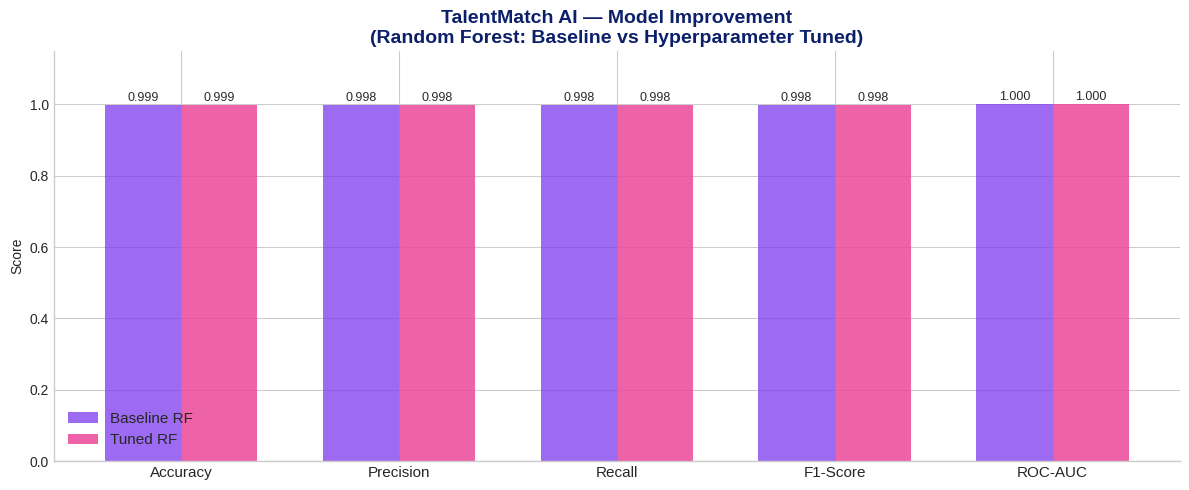

✅ Model improvement chart disimpan: model_improvement.png


In [57]:
# ============================================================
# VISUALISASI BEFORE vs AFTER TUNING
# ============================================================

metrics_list = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
before_vals  = [
    rf_baseline['accuracy'], rf_baseline['precision'],
    rf_baseline['recall'],   rf_baseline['f1'],   rf_baseline['roc_auc']
]
after_vals   = [
    accuracy_score(y1_test, y_pred_tuned),
    precision_score(y1_test, y_pred_tuned, zero_division=0),
    recall_score(y1_test, y_pred_tuned, zero_division=0),
    f1_score(y1_test, y_pred_tuned, zero_division=0),
    roc_auc_score(y1_test, y_prob_tuned)
]

x   = np.arange(len(metrics_list))
w   = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
b1 = ax.bar(x - w/2, before_vals, w, label='Baseline RF', color=PRIMARY,   alpha=0.75)
b2 = ax.bar(x + w/2, after_vals,  w, label='Tuned RF',    color=SECONDARY, alpha=0.85)

for bar in b1:
    ax.annotate(f'{bar.get_height():.3f}',
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 3), textcoords='offset points',
                ha='center', fontsize=9)
for bar in b2:
    ax.annotate(f'{bar.get_height():.3f}',
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 3), textcoords='offset points',
                ha='center', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(metrics_list, fontsize=11)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score')
ax.legend(fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_title('TalentMatch AI — Model Improvement\n(Random Forest: Baseline vs Hyperparameter Tuned)',
             fontsize=14, fontweight='bold', color=DARK_BLUE)
plt.tight_layout()
plt.savefig('model_improvement.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('✅ Model improvement chart disimpan: model_improvement.png')

In [58]:
# ============================================================
# D4. FINAL SUMMARY TABLE — Semua Output Stage 3
# ============================================================

print('='*70)
print('  ✅ STAGE 3 SELESAI — RINGKASAN OUTPUT')
print('='*70)

outputs = [
    ('A. Model Evaluation'    , 'model_evaluation_heatmap.png'),
    ('A. Model Comparison'    , 'model_comparison_bar.png'),
    ('A. Gap Train vs Test'   , 'gap_train_test.png'),
    ('A. Confusion Matrix M1' , 'confusion_matrix_model1.png'),
    ('A. Confusion Matrix M2' , 'confusion_matrix_model2.png'),
    ('A. ROC Curve'           , 'roc_curve_comparison.png'),
    ('B. Feature Importance'  , 'feature_importance.png'),
    ('B. SHAP Summary'        , 'shap_summary.png'),
    ('B. SHAP Bar'            , 'shap_bar.png'),
    ('B. SHAP Waterfall'      , 'shap_waterfall.png'),
    ('B. LIME Explanation'    , 'lime_explanation.png'),
    ('B. Fairness Analysis'   , 'fairness_analysis.png'),
    ('C. Error Analysis'      , 'error_analysis_features.png'),
    ('C. Financial Impact'    , 'financial_impact.png'),
    ('C. Time Efficiency'     , 'time_efficiency.png'),
    ('D. Model Improvement'   , 'model_improvement.png'),
]

for section, fname in outputs:
    print(f'  ✅ {section:<30} → {fname}')

print()
print('  🎯 Siap untuk Reporting & Presentation!')
print('  💡 Gunakan file PNG di atas untuk mengisi slide PPT Stage 3')

  ✅ STAGE 3 SELESAI — RINGKASAN OUTPUT
  ✅ A. Model Evaluation            → model_evaluation_heatmap.png
  ✅ A. Model Comparison            → model_comparison_bar.png
  ✅ A. Gap Train vs Test           → gap_train_test.png
  ✅ A. Confusion Matrix M1         → confusion_matrix_model1.png
  ✅ A. Confusion Matrix M2         → confusion_matrix_model2.png
  ✅ A. ROC Curve                   → roc_curve_comparison.png
  ✅ B. Feature Importance          → feature_importance.png
  ✅ B. SHAP Summary                → shap_summary.png
  ✅ B. SHAP Bar                    → shap_bar.png
  ✅ B. SHAP Waterfall              → shap_waterfall.png
  ✅ B. LIME Explanation            → lime_explanation.png
  ✅ B. Fairness Analysis           → fairness_analysis.png
  ✅ C. Error Analysis              → error_analysis_features.png
  ✅ C. Financial Impact            → financial_impact.png
  ✅ C. Time Efficiency             → time_efficiency.png
  ✅ D. Model Improvement           → model_improvement.png

  🎯 Siap

# **SAVE DEPLOYMENT OBJECTS**

In [70]:
# ==========================================================
# SAVE DEPLOYMENT OBJECTS
# ==========================================================

import joblib
import os

os.makedirs("models", exist_ok=True)

#simpan final model

joblib.dump(
    best_gb_model,
    "models/gradient_boosting_model.pkl"
)

['models/gradient_boosting_model.pkl']

In [71]:
joblib.dump(
    scaler2,
    "models/scaler.pkl"
)

['models/scaler.pkl']

In [72]:
loaded_model = joblib.load("models/gradient_boosting_model.pkl")

In [73]:
encoders = {
    "education_level": le_edu,
    "internal_referral": le_ref,
    "hiring_eligibility": le_tgt,
    "seniority_tier": le_tier

}

if "le_exp" in locals():
    encoders["exp_level"] = le_exp

    joblib.dump(
    encoders,
    "models/label_encoders.pkl"
)

In [74]:
feature_order = X2.columns.tolist()

joblib.dump(
    feature_order,
    "models/feature_order.pkl"
)

['models/feature_order.pkl']

In [75]:
skill_columns = skills_dummies.columns.tolist()

joblib.dump(
    skill_columns,
    "models/skill_columns.pkl"
)

['models/skill_columns.pkl']

In [80]:
from google.colab import drive
drive.mount('/content/drive')

import os

print(os.listdir("/content/drive"))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['.shortcut-targets-by-id', 'MyDrive', '.Trash-0', '.Encrypted']
